 # REFMAP laboratory listening test 1 analysis: Rough confirmatory data analysis



 ## Setup


In [122]:
# import packages
import sys
import os
import numpy as np
import pandas as pd
from PyQt5.QtWidgets import QFileDialog, QApplication
from scipy import stats
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.collections import PathCollection
from matplotlib.legend_handler import HandlerPathCollection, HandlerLine2D
import seaborn as sns
import dabest
import warnings
from refmap_psychoacoustics.utils.format_helpers import (round_trad, display_round)

# Suppress FutureWarning messages to quiet pandas
warnings.simplefilter(action='ignore', category=FutureWarning)

# enable copy-on-write mode for Pandas (will be default from Pandas 3.0)
pd.options.mode.copy_on_write = True


In [2]:
# set plot parameters
sns.set_style('white')
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
mpl.rcParams.update({'font.size': 16})
mpl.rcParams['figure.autolayout'] = True
mpl.rcParams['mathtext.fontset'] = 'stix'

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE,
       labelsize=MEDIUM_SIZE)    # fontsize of the axes title and x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

mycolours = [(0, 102, 255), (0, 204, 153), (255, 0, 102), (74, 111, 152),
             (251, 164, 49), (204, 153, 255), (90, 192, 255), (80, 245, 233),
             (255, 90, 192), (164, 201, 242), (255, 254, 139), (255, 243, 255)]
mycolours = [tuple(shade/255 for shade in colour) for colour in mycolours]

np.random.seed(303)

# enable copy-on-write mode for Pandas (will be default from Pandas 3.0)
pd.options.mode.copy_on_write = True

# check/open QApplication instance
if not QApplication.instance():
    app = QApplication(sys.argv)
else:
    app = QApplication.instance() 



 Set the saveplots toggle to True if plot saving is desired:

In [3]:
saveplots = True

if saveplots:
    # select figure output save path
    outFigPath = QFileDialog.getExistingDirectory(caption=r"Select output folder to save plots in: 03 Experiment\Experiment 1\Analysis\Plots")

    # create subfolders if not already existing
    try:
        os.mkdir(os.path.join(outFigPath, "svg"))
    except FileExistsError:
        pass

    try:
        os.mkdir(os.path.join(outFigPath, "pdf"))
    except FileExistsError:
        pass



 ## Import data and organise

In [123]:
# import test data
fileExts = "*.csv"

# Part A
dataBySubjAFilePath = list(QFileDialog.getOpenFileName(filter="refmap_listest1_testdataA_BySubj.csv",
                                                       caption=r"Open refmap_listest1_testdataA_BySubj.csv in: \03 Experiment\Experiment 1\Analysis\PostProcess"))[0]
dataBySubjTestA = pd.read_csv(dataBySubjAFilePath, low_memory=False)

# Part B
dataBySubjBFilePath = list(QFileDialog.getOpenFileName(filter="refmap_listest1_testdataB_BySubj.csv",
                                                       caption=r"Open refmap_listest1_testdataB_BySubj.csv in: \03 Experiment\Experiment 1\Analysis\PostProcess"))[0]
dataBySubjTestB = pd.read_csv(dataBySubjBFilePath, low_memory=False)

# Both parts
dataBySubjFilePath = list(QFileDialog.getOpenFileName(filter="refmap_listest1_testdata_BySubj.csv",
                                                       caption=r"Open refmap_listest1_testdata_BySubj.csv in: \03 Experiment\Experiment 1\Analysis\PostProcess"))[0]
dataBySubjTest = pd.read_csv(dataBySubjFilePath, low_memory=False)



In [5]:
# categorise columns

for dataset in [dataBySubjTestA, dataBySubjTest]:
    dataset['AmbientEnv'] = pd.Categorical(dataset['AmbientEnv'], ["Park", "Street"])
    dataset['SNRlevel'] = pd.Categorical(dataset['SNRlevel'], ["Baseline", "-16", "-10", "-4", "2", "8"], ordered=True)
    dataset['UASLAeq'] = pd.Categorical(dataset['UASLAeq'], ["Baseline", "42", "48", "54", "60"], ordered=True)
    dataset['UASOperation'] = pd.Categorical(dataset['UASOperation'], ["Baseline", "Overflight", "Landing", "Takeoff"])
    dataset['UASType'] = pd.Categorical(dataset['UASType'], ["Baseline", "H520", "M300", "T150"])

for dataset in [dataBySubjTestB]:
    dataset['AmbientEnv'] = pd.Categorical(dataset['AmbientEnv'], ["Park", "Street"])
    dataset['SNRlevel'] = pd.Categorical(dataset['SNRlevel'], ["Baseline", "2", "8"], ordered=True)
    dataset['UASLAeq'] = pd.Categorical(dataset['UASLAeq'], ["Baseline", "54", "60"], ordered=True)
    dataset['UASOperation'] = pd.Categorical(dataset['UASOperation'], ["Baseline", "Overflight"])
    dataset['UASType'] = pd.Categorical(dataset['UASType'], ["Baseline", "H520", "T150"])



 ## Setup output dataframes

In [6]:
out = pd.DataFrame()
outd = pd.DataFrame()

savedata = True

if savedata:
    # select data output save path
    outDataPath = QFileDialog.getExistingDirectory(caption=r"Select output folder to save output data in: \03 Experiment\Experiment 1\Analysis\Python")



 ## Part A



 ### Scaled vs modelled UAS LAeq level 2

In [7]:
# select subset of data for analysis and sort
data = dataBySubjTestA[dataBySubjTestA['StimFile'].str.contains("_F_2")]
data = data.loc[:, ['ID', 'StimFile', 'UASType', 'AmbientEnv', 'Annoyance']]
data.sort_values(by=['ID', 'StimFile'], inplace=True)

# drop the "Baseline" category and convert to plain string columns. These
# are also the columns used for x=/color_col=/grouping_cols downstream, and
# dabest's own category-reordering code (inside dabest.load()/  .plot())
# turns out to be unreliable once a categorical column has had categories
# removed -- converting away from pandas' Categorical dtype entirely
# sidesteps that fragility, since dabest then just builds its own ordered
# categorical fresh from the values actually present.
data['UASType'] = data['UASType'].astype(str)
data['AmbientEnv'] = data['AmbientEnv'].astype(str)

# add column to indicate modelled or scaled, and create a dummy pairing ID
data['LvlType'] = "Modelled"
data.loc[data['StimFile'].str.contains("PwrScale"), 'LvlType'] = "Scaled"

grouping_cols = ['ID', 'UASType', 'AmbientEnv']

# ngroup() automatically assigns an identical integer to matching sets
# across the different level-type conditions
data['dummyID'] = data.groupby(grouping_cols).ngroup() + 1
data.sort_values(by=['dummyID', 'ID', 'StimFile'], inplace=True)




In [8]:
# assign data for processing
dataloadBL = dabest.load(ps_adjust=True, data=data, idx=("Modelled", "Scaled"), x='LvlType', y='Annoyance', paired='baseline',
                         id_col='dummyID', resamples=5000, random_seed=303)



,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Modelled,Scaled,246,246,mean difference,baseline,0.056911,95,-0.191057,0.321138,0.643071,0.69952,7362.0,0.662346,-0.437207


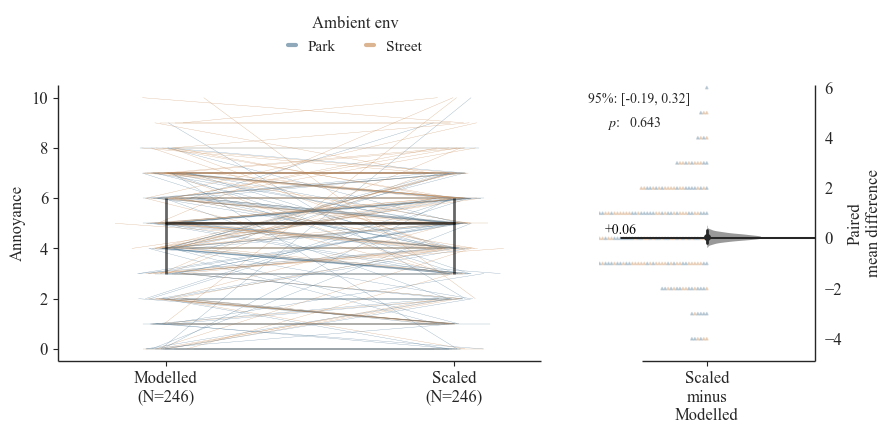

In [9]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(9, 4.5))
dataMD = dataloadBL.mean_diff.plot(contrast_bars=False, show_baseline_ec=True,
                                   group_summaries='median_quartiles',
                                   raw_ylim=(-0.5, 10.5), color_col='AmbientEnv',
                                   slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.6, 'jitter': 0.3},
                                   delta_dot_kwargs={'size': 0.75, 'side': 'left',
                                                     'alpha': 0.25, 'zorder': 1},
                                   delta_text=True, contrast_marker_size=4, contrast_ylim=(-5.5, 4.5),
                                   legend_kwargs={'bbox_to_anchor': [-1.5, 1.3], 'fontsize': 11,
                                                  'ncol': 2, 'title': r'Ambient env'}, ax=ax)

diffs = dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values

contrast_ax = ax.contrast_axes

# label results
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=ii + 0.45, y=5.4, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=ii + 0.54, y=4.45, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)


if saveplots:
    
    filename = "PtALvlScaleDabest"
    
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests



In [10]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Modelled,Scaled,246,246,Cohen's d,baseline,0.0239,95,-0.080399,0.135547,0.643071,0.69952,7362.0,0.662346,-0.437207


 ### UAS LAeq segregated by ambient environment

In [11]:
# select subset of data for analysis and sort
data = dataBySubjTestA[~dataBySubjTestA['StimFile'].str.contains("PwrScale")]
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'AmbientEnv', 'UASLAeq', 'UASType', 'UASOperation', 'Annoyance']]
data.sort_values(by=['ID', 'AmbientEnv', 'UASOperation', 'UASType', 'UASLAeq'], inplace=True)

dataPk = data.loc[data['AmbientEnv'] == "Park", :]
dataSt = data.loc[data['AmbientEnv'] == "Street", :]

# drop the "Baseline" category by converting to plain string columns
for dataset in [dataPk, dataSt]:
    dataset['UASLAeq'] = dataset['UASLAeq'].astype(str)
    dataset['UASType'] = dataset['UASType'].astype(str)
    dataset['UASOperation'] = dataset['UASOperation'].astype(str)

# create dummy pairing ID for each participant to allow for paired analysis
grouping_cols = ['ID', 'UASType', 'UASOperation']

# ngroup() automatically assigns an identical integer to matching sets
# across the different UAS LAeq conditions
dataPk['dummyID'] = dataPk.groupby(grouping_cols).ngroup() + 1
dataSt['dummyID'] = dataSt.groupby(grouping_cols).ngroup() + 1
dataPk.sort_values(by=['dummyID', 'ID', 'StimFile'], inplace=True)
dataSt.sort_values(by=['dummyID', 'ID', 'StimFile'], inplace=True)



In [12]:
# assign data for processing
dataPkloadSQ = dabest.load(ps_adjust=True, data=dataPk, idx=("42", "48", "54", "60"), x='UASLAeq', y='Annoyance', paired='sequential',
                           id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=303)
dataStloadSQ = dabest.load(ps_adjust=True, data=dataSt, idx=("42", "48", "54", "60"), x='UASLAeq', y='Annoyance', paired='sequential',
                           id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=303)


C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\2588002829.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\2588002829.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\2588002829.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,42,48,369,369,41,mean difference,sequential,0.951220,95,0.734417,1.165312,0.0002,1.012021e-15,8576.0,2.420381e-15,-8.273149
1,48,54,369,369,41,mean difference,sequential,0.861789,95,0.598916,1.116531,0.0002,2.516079e-13,10578.5,5.236929e-12,-7.133314
2,54,60,369,369,41,mean difference,sequential,0.978320,95,0.704607,1.322493,0.0002,1.623886e-12,10817.5,1.563889e-13,-7.669002


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


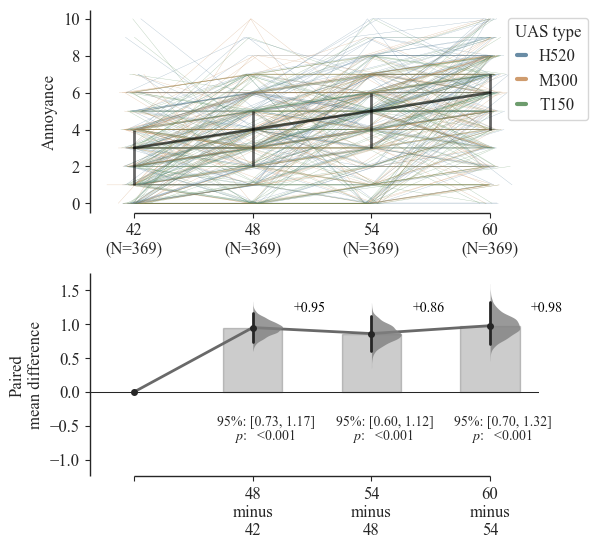

In [13]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataPkMD = dataPkloadSQ.mean_diff.plot(contrast_bars=True,
                                       group_summaries='median_quartiles',
                                   raw_ylim=(-0.5, 10.5), color_col='UASType',
                                       delta_dot=False,
                                       slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                       contrast_marker_size=4,
                                       contrast_ylim=(-1.25, 1.75),
                                       float_contrast=True,
                                       delta_text=True,
                                       delta_text_kwargs={'y_coordinates':[1.25]*(len(data['UASLAeq'].unique()) - 1)},
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS type", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = dataPkloadSQ.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=-0.5, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.84 + ii, y=-0.7, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legend_handles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    filename = "PtALAeqParkDabest"
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataPkMD;
dataPkloadSQ.mean_diff.statistical_tests



In [14]:
out = pd.concat([out, dataPkloadSQ.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataPkloadSQ.cohens_d.statistical_tests])
dataPkloadSQ.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,42,48,369,369,41,Cohen's d,sequential,0.455334,95,0.339094,0.567223,0.0002,1.012021e-15,8576.0,2.420381e-15,-8.273149
1,48,54,369,369,41,Cohen's d,sequential,0.375490,95,0.241124,0.498752,0.0002,2.516079e-13,10578.5,5.236929e-12,-7.133314
2,54,60,369,369,41,Cohen's d,sequential,0.401178,95,0.289261,0.532613,0.0002,1.623886e-12,10817.5,1.563889e-13,-7.669002


C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\536582520.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\536582520.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\536582520.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,42,48,369,369,41,mean difference,sequential,0.371274,95,0.143631,0.552846,0.0014,6.386729e-04,12043.5,6.801265e-04,-3.426642
1,48,54,369,369,41,mean difference,sequential,0.384824,95,0.216802,0.569106,0.0002,1.502871e-04,13070.0,6.531619e-04,-3.437966
2,54,60,369,369,41,mean difference,sequential,0.959350,95,0.696477,1.325203,0.0002,6.468262e-16,9045.5,4.711984e-15,-8.178623


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


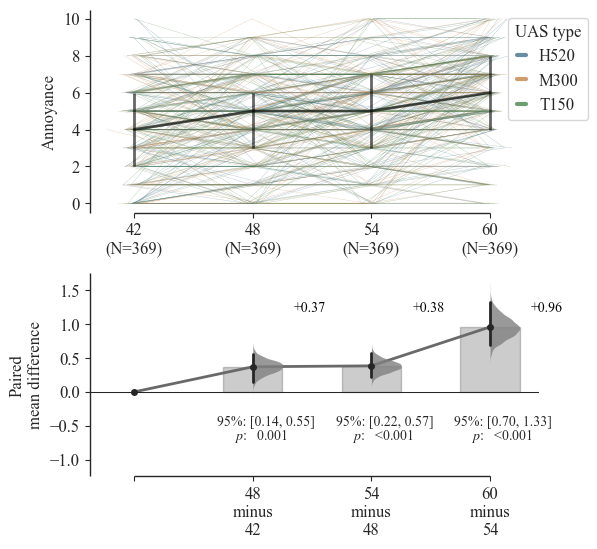

In [15]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataStMD = dataStloadSQ.mean_diff.plot(contrast_bars=True,
                                       group_summaries='median_quartiles',
                                   raw_ylim=(-0.5, 10.5), color_col='UASType',
                                       delta_dot=False,
                                       slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                       contrast_marker_size=4,
                                       contrast_ylim=(-1.25, 1.75),
                                       float_contrast=True,
                                       delta_text=True,
                                       delta_text_kwargs={'y_coordinates':[1.25]*(len(data['UASLAeq'].unique()) - 1)},
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS type", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = dataStloadSQ.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=-0.5, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.84 + ii, y=-0.7, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legend_handles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:

    filename = "PtALAeqStreetDabest"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataStMD;
dataStloadSQ.mean_diff.statistical_tests



In [16]:
out = pd.concat([out, dataStloadSQ.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataStloadSQ.cohens_d.statistical_tests])
dataStloadSQ.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,42,48,369,369,41,Cohen's d,sequential,0.155188,95,0.060409,0.232351,0.0012,6.386729e-04,12043.5,6.801265e-04,-3.426642
1,48,54,369,369,41,Cohen's d,sequential,0.162379,95,0.087082,0.243468,0.0002,1.502871e-04,13070.0,6.531619e-04,-3.437966
2,54,60,369,369,41,Cohen's d,sequential,0.403855,95,0.271984,0.554232,0.0002,6.468262e-16,9045.5,4.711984e-15,-8.178623


 ### UAS types and operations segregated by ambient environment



 #### UAS type

In [17]:
# select subset of data for analysis and sort
data = dataBySubjTestA[~dataBySubjTestA['StimFile'].str.contains("PwrScale")]
data = data[data['UASType'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'AmbientEnv', 'UASLAeq', 'UASType', 'UASOperation', 'Annoyance']]
data.sort_values(by=['ID', 'UASLAeq', 'UASOperation', 'UASType', 'AmbientEnv'], inplace=True)

dataPk = data.loc[data['AmbientEnv'] == "Park", :]
dataSt = data.loc[data['AmbientEnv'] == "Street", :]

# drop the "Baseline" category by converting to plain string columns
for dataset in [dataPk, dataSt]:
    dataset['UASLAeq'] = dataset['UASLAeq'].astype(str)
    dataset['UASType'] = dataset['UASType'].astype(str)
    dataset['UASOperation'] = dataset['UASOperation'].astype(str)

# create dummy pairing ID for each participant to allow for paired analysis
grouping_cols = ['ID', 'UASLAeq', 'UASOperation']

# ngroup() automatically assigns an identical integer to matching sets
# across the different UAS type conditions
dataPk['dummyID'] = dataPk.groupby(grouping_cols).ngroup() + 1
dataSt['dummyID'] = dataSt.groupby(grouping_cols).ngroup() + 1
dataPk.sort_values(by=['dummyID', 'ID', 'StimFile'], inplace=True)
dataSt.sort_values(by=['dummyID', 'ID', 'StimFile'], inplace=True)



In [18]:
# assign data for processing
dataPkloadBL = dabest.load(ps_adjust=True, data=dataPk, idx=("H520", "M300", "T150"), x='UASType', y='Annoyance', paired='baseline',
                           id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=303)
dataStloadBL = dabest.load(ps_adjust=True, data=dataSt, idx=("H520", "M300", "T150"), x='UASType', y='Annoyance', paired='baseline',
                           id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=303)



C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\4087680684.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\4087680684.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\4087680684.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,H520,M300,492,492,41,mean difference,baseline,-0.357724,95,-0.571138,-0.152439,0.0012,0.001376,23542.0,0.000754,3.390566
1,H520,T150,492,492,41,mean difference,baseline,-0.449187,95,-0.715447,-0.186992,0.0018,0.000021,27984.5,0.000028,4.231828


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


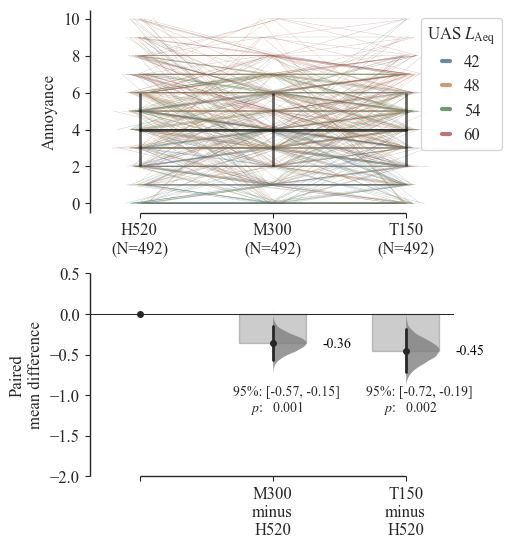

In [19]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(5.14, 3))
dataPkMD = dataPkloadBL.mean_diff.plot(contrast_bars=True,
                                       group_summaries='median_quartiles',
                                        raw_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                       delta_dot=False,
                                       slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                       contrast_marker_size=4,
                                       contrast_ylim=(-2, 0.5),
                                       float_contrast=True,
                                       contrast_paired_lines=False,
                                       delta_text=True,
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = dataPkloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=-1, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.74 + ii + 0.09, y=-1.2, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legend_handles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:

    filename = "PtATypeParkDabest"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataPkMD;
dataPkloadBL.mean_diff.statistical_tests



In [20]:
out = pd.concat([out, dataPkloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataPkloadBL.cohens_d.statistical_tests])
dataPkloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,H520,M300,492,492,41,Cohen's d,baseline,-0.143211,95,-0.226385,-0.057556,0.0012,0.001376,23542.0,0.000754,3.390566
1,H520,T150,492,492,41,Cohen's d,baseline,-0.177829,95,-0.283487,-0.071914,0.0018,0.000021,27984.5,0.000028,4.231828


C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\812043894.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\812043894.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\812043894.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,H520,M300,492,492,41,mean difference,baseline,-0.085366,95,-0.221545,0.065041,0.248950,0.205018,27046.0,0.374111,0.889610
1,H520,T150,492,492,41,mean difference,baseline,-0.197154,95,-0.359756,-0.048780,0.021196,0.006711,23282.5,0.031394,2.158231


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


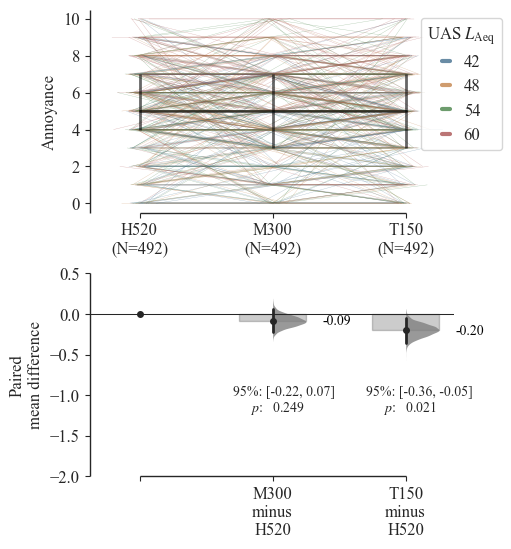

In [21]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(5.14, 3))
dataStMD = dataStloadBL.mean_diff.plot(contrast_bars=True,
                                       group_summaries='median_quartiles',
                                        raw_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                       delta_dot=False,
                                       slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                       contrast_marker_size=4,
                                       contrast_ylim=(-2, 0.5), float_contrast=True,
                                       delta_text=True,
                                       contrast_paired_lines=False,
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)

diffs = dataStloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=-1, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.74 + ii + 0.09, y=-1.2, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legend_handles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:

    filename = "PtATypeStreetDabest"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')


dataStMD;
dataStloadBL.mean_diff.statistical_tests



In [22]:
out = pd.concat([out, dataStloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataStloadBL.cohens_d.statistical_tests])
dataStloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,H520,M300,492,492,41,Cohen's d,baseline,-0.034743,95,-0.090831,0.029252,0.248950,0.205018,27046.0,0.374111,0.889610
1,H520,T150,492,492,41,Cohen's d,baseline,-0.079948,95,-0.148082,-0.015914,0.021196,0.006711,23282.5,0.031394,2.158231


In [23]:
# assign data for processing
dataPkHiloadBL = dabest.load(ps_adjust=True, data=dataPk.loc[dataPk['UASLAeq'] == '60'], idx=("H520", "M300", "T150"), x='UASType', y='Annoyance', paired='baseline',
                             id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=12345)
dataStHiloadBL = dabest.load(ps_adjust=True, data=dataSt.loc[dataSt['UASLAeq'] == '60'], idx=("H520", "M300", "T150"), x='UASType', y='Annoyance', paired='baseline',
                             id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=12345)

C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3502177299.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3502177299.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3502177299.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,H520,M300,123,123,41,mean difference,baseline,-0.943089,95,-1.520325,-0.520325,0.000400,0.000034,1083.5,0.000043,4.245150
1,H520,T150,123,123,41,mean difference,baseline,-0.747967,95,-1.227642,-0.268293,0.002799,0.001863,1938.0,0.001167,3.325376


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


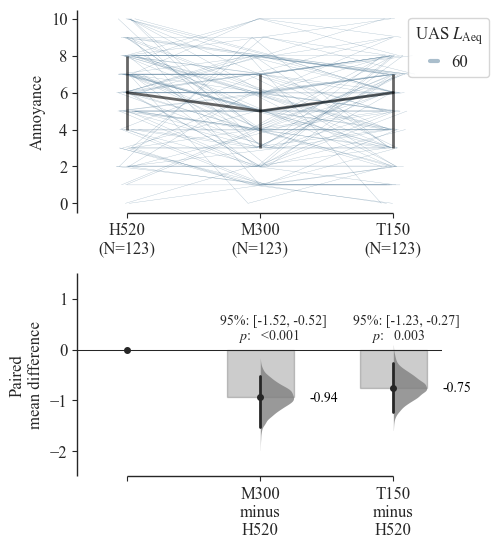

In [24]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(5.14, 3))
dataPkHiMD = dataPkHiloadBL.mean_diff.plot(contrast_bars=True,
                                           group_summaries='median_quartiles',
                                            raw_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                           delta_dot=False,
                                           slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                           contrast_marker_size=4,
                                           contrast_ylim=(-2.5, 1.5),
                                           contrast_paired_lines=False,
                                           float_contrast=True,
                                           delta_text=True,
                                           legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                          'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = dataPkHiloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=0.5, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.74 + ii + 0.09, y=0.2, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

if saveplots:

    filename = "PtATypeParkHiDabest"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataPkHiMD;
dataPkHiloadBL.mean_diff.statistical_tests



In [25]:
out = pd.concat([out, dataPkHiloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataPkHiloadBL.cohens_d.statistical_tests])
dataPkHiloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,H520,M300,123,123,41,Cohen's d,baseline,-0.385177,95,-0.613506,-0.200336,0.0004,0.000034,1083.5,0.000043,4.245150
1,H520,T150,123,123,41,Cohen's d,baseline,-0.306181,95,-0.507063,-0.097423,0.0024,0.001863,1938.0,0.001167,3.325376


C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\368740572.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\368740572.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\368740572.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,H520,M300,123,123,41,mean difference,baseline,-0.219512,95,-0.552846,0.113821,0.221156,0.263260,1773.5,0.297701,1.045843
1,H520,T150,123,123,41,mean difference,baseline,-0.341463,95,-0.650407,-0.081301,0.028994,0.026306,1334.0,0.032420,2.163910


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


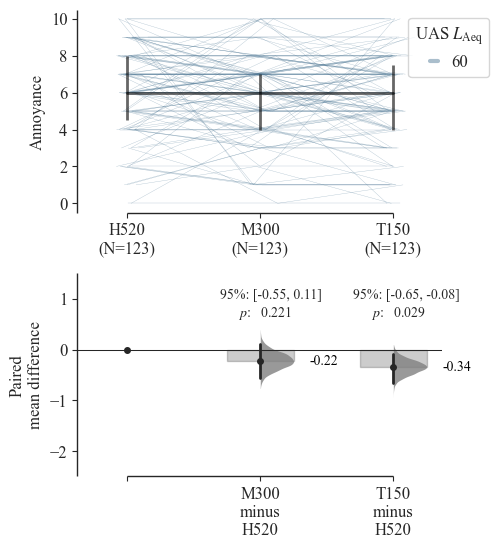

In [26]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(5.14, 3))
dataStHiMD = dataStHiloadBL.mean_diff.plot(contrast_bars=True,
                                           group_summaries='median_quartiles',
                                   raw_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                           delta_dot=False,
                                           slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                           contrast_marker_size=4, contrast_ylim=(-2.5, 1.5), float_contrast=True,
                                           contrast_paired_lines=False,
                                           delta_text=True,
                                           legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                          'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = dataStHiloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=1, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.74 + ii + 0.09, y=0.65, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

if saveplots:

    filename = "PtATypeStreetHiDabest"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataStHiMD;
dataStHiloadBL.mean_diff.statistical_tests



In [27]:
out = pd.concat([out, dataStHiloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataStHiloadBL.cohens_d.statistical_tests])
dataStHiloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,H520,M300,123,123,41,Cohen's d,baseline,-0.092979,95,-0.231149,0.056441,0.221156,0.263260,1773.5,0.297701,1.045843
1,H520,T150,123,123,41,Cohen's d,baseline,-0.142476,95,-0.262467,-0.027595,0.028994,0.026306,1334.0,0.032420,2.163910


 #### Flight operation

In [28]:
# select subset of data for analysis and sort
data = dataBySubjTestA[~dataBySubjTestA['StimFile'].str.contains("PwrScale")]
data = data[data['UASType'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'AmbientEnv', 'UASLAeq', 'UASType', 'UASOperation', 'Annoyance']]
data.sort_values(by=['ID', 'UASLAeq', 'UASType', 'AmbientEnv', 'UASOperation'], inplace=True)

dataPk = data.loc[data['AmbientEnv'] == "Park", :]
dataSt = data.loc[data['AmbientEnv'] == "Street", :]

# drop the "Baseline" category by converting to plain string columns
data['UASLAeq'] = data['UASLAeq'].astype(str)
data['UASType'] = data['UASType'].astype(str)
data['UASOperation'] = data['UASOperation'].astype(str)
for dataset in [dataPk, dataSt]:
    dataset['UASLAeq'] = dataset['UASLAeq'].astype(str)
    dataset['UASType'] = dataset['UASType'].astype(str)
    dataset['UASOperation'] = dataset['UASOperation'].astype(str)

# create dummy pairing ID for each participant to allow for paired analysis
grouping_cols_all = ['ID', 'AmbientEnv', 'UASLAeq', 'UASType']
grouping_cols_env = ['ID', 'UASLAeq', 'UASType']

# ngroup() automatically assigns an identical integer to matching sets
# across the different flight-operation conditions
data['dummyID'] = data.groupby(grouping_cols_all).ngroup() + 1
dataPk['dummyID'] = dataPk.groupby(grouping_cols_env).ngroup() + 1
dataSt['dummyID'] = dataSt.groupby(grouping_cols_env).ngroup() + 1
data.sort_values(by=['dummyID', 'ID', 'StimFile'], inplace=True)
dataPk.sort_values(by=['dummyID', 'ID', 'StimFile'], inplace=True)
dataSt.sort_values(by=['dummyID', 'ID', 'StimFile'], inplace=True)



In [29]:
# assign data for processing
dataloadBL = dabest.load(ps_adjust=True, data=data, idx=("Overflight", "Landing", "Takeoff"), x='UASOperation', y='Annoyance',
                         paired='baseline', id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=303)
dataPkloadBL = dabest.load(ps_adjust=True, data=dataPk, idx=("Overflight", "Landing", "Takeoff"), x='UASOperation', y='Annoyance',
                           paired='baseline', id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=303)
dataStloadBL = dabest.load(ps_adjust=True, data=dataSt, idx=("Overflight", "Landing", "Takeoff"), x='UASOperation', y='Annoyance',
                           paired='baseline', id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=303)



C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\1721836520.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\1721836520.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\1721836520.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Overflight,Landing,984,984,41,mean difference,baseline,0.311992,95,0.153455,0.455285,0.0002,8.734782e-07,98564.0,1.366143e-05,-4.371361
1,Overflight,Takeoff,984,984,41,mean difference,baseline,0.445122,95,0.244919,0.675813,0.0002,1.466700e-09,99960.5,3.440872e-09,-5.963452


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


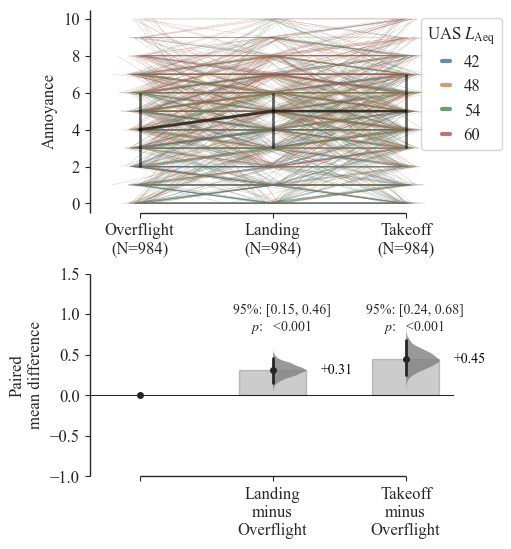

In [30]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(5.14, 3))
dataMD = dataloadBL.mean_diff.plot(contrast_bars=True,
                                   group_summaries='median_quartiles',
                                   raw_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                   delta_dot=False,
                                   slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                   contrast_marker_size=4, contrast_ylim=(-1, 1.5), float_contrast=True,
                                   contrast_paired_lines=False,
                                   delta_text=True,
                                   legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                  'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=1.0, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.74 + ii + 0.09, y=0.8, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legend_handles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:

    filename = "PtAOpDabest"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests



In [31]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Overflight,Landing,984,984,41,Cohen's d,baseline,0.125200,95,0.059132,0.181273,0.0002,8.734782e-07,98564.0,1.366143e-05,-4.371361
1,Overflight,Takeoff,984,984,41,Cohen's d,baseline,0.177272,95,0.097240,0.260683,0.0002,1.466700e-09,99960.5,3.440872e-09,-5.963452


C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\916513662.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\916513662.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\916513662.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Overflight,Landing,492,492,41,mean difference,baseline,0.353659,95,0.142276,0.552846,0.0006,0.000191,24936.0,0.000730,-3.399509
1,Overflight,Takeoff,492,492,41,mean difference,baseline,0.430894,95,0.193089,0.674797,0.0016,0.000087,26950.5,0.000068,-4.017696


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


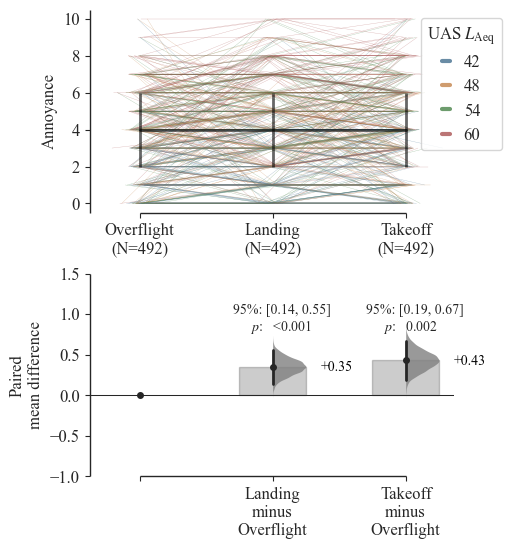

In [32]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(5.14, 3))
dataPkMD = dataPkloadBL.mean_diff.plot(contrast_bars=True,
                                       group_summaries='median_quartiles',
                                       raw_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                       delta_dot=False,
                                       slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                       contrast_marker_size=4, contrast_ylim=(-1, 1.5), float_contrast=True,
                                       contrast_paired_lines=False,
                                       delta_text=True,
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = dataPkloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=1.0, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.74 + ii + 0.09, y=0.8, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legend_handles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:

    filename = "PtAOpParkDabest"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataPkMD;
dataPkloadBL.mean_diff.statistical_tests



In [33]:
out = pd.concat([out, dataPkloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataPkloadBL.cohens_d.statistical_tests])
dataPkloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Overflight,Landing,492,492,41,Cohen's d,baseline,0.143209,95,0.058324,0.221105,0.0006,0.000191,24936.0,0.000730,-3.399509
1,Overflight,Takeoff,492,492,41,Cohen's d,baseline,0.175236,95,0.078205,0.271965,0.0016,0.000087,26950.5,0.000068,-4.017696


C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\1234886920.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\1234886920.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\1234886920.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Overflight,Landing,492,492,41,mean difference,baseline,0.270325,95,0.069106,0.432927,0.004399,0.001284,24420.5,0.005928,-2.763793
1,Overflight,Takeoff,492,492,41,mean difference,baseline,0.459350,95,0.223577,0.735772,0.001000,0.000004,23199.0,0.000012,-4.419069


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


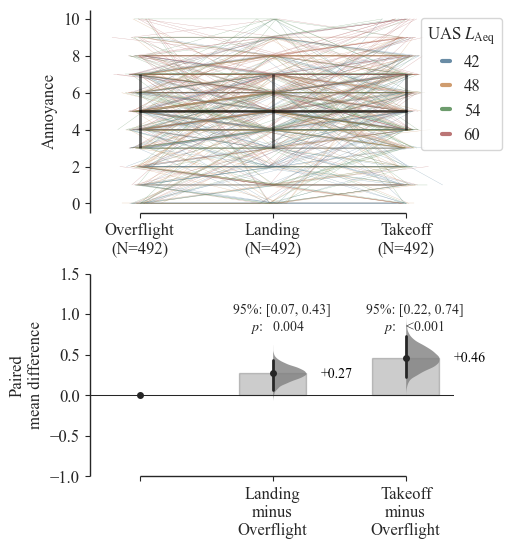

In [34]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(5.14, 3))
dataStMD = dataStloadBL.mean_diff.plot(contrast_bars=True,
                                       group_summaries='median_quartiles',
                                   raw_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                       delta_dot=False,
                                       slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                       contrast_marker_size=4, contrast_ylim=(-1, 1.5), float_contrast=True,
                                       contrast_paired_lines=False,
                                       delta_text=True,
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)

diffs = dataStloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=1.0, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.74 + ii + 0.09, y=0.8, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legend_handles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:

    filename = "PtAOpStreetDabest"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataStMD;
dataStloadBL.mean_diff.statistical_tests



In [35]:
out = pd.concat([out, dataStloadBL.mean_diff.statistical_tests])    
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataStloadBL.cohens_d.statistical_tests])
dataStloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Overflight,Landing,492,492,41,Cohen's d,baseline,0.110748,95,0.022028,0.175492,0.004399,0.001284,24420.5,0.005928,-2.763793
1,Overflight,Takeoff,492,492,41,Cohen's d,baseline,0.185207,95,0.088991,0.291559,0.001000,0.000004,23199.0,0.000012,-4.419069


In [36]:
# assign data for processing
dataHiloadBL = dabest.load(ps_adjust=True, data=data.loc[data['UASLAeq'] == '60'], idx=("Overflight", "Landing", "Takeoff"),
                           x='UASOperation', y='Annoyance', paired='baseline',
                           id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=303)



C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\896072715.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\896072715.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\896072715.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Overflight,Landing,246,246,41,mean difference,baseline,0.333333,95,-0.048780,0.638211,0.059988,0.009347,7363.0,0.035173,-2.118107
1,Overflight,Takeoff,246,246,41,mean difference,baseline,0.796748,95,0.422764,1.211382,0.000400,0.000003,6319.5,0.000001,-4.981410


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


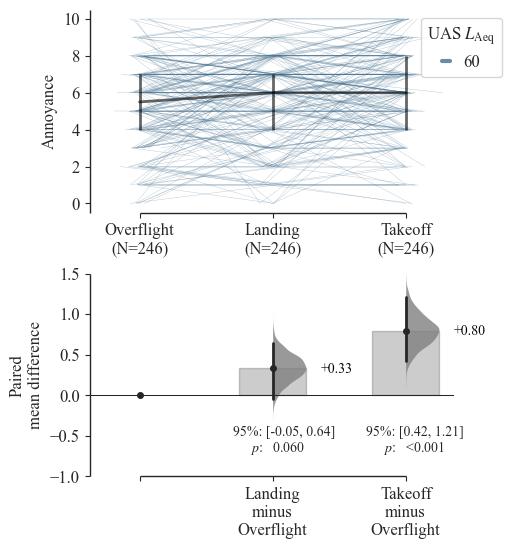

In [37]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(5.14, 3))
dataHiMD = dataHiloadBL.mean_diff.plot(contrast_bars=True,
                                      group_summaries='median_quartiles',
                                   raw_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                       delta_dot=False,
                                       slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                       contrast_marker_size=4, contrast_ylim=(-1, 1.5), float_contrast=True,
                                       contrast_paired_lines=False,
                                       delta_text=True,
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = dataHiloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=-0.5, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.74 + ii + 0.09, y=-0.7, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legend_handles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:

    filename = "PtAOpHiDabest"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataHiMD;
dataHiloadBL.mean_diff.statistical_tests



In [38]:
out = pd.concat([out, dataHiloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataHiloadBL.cohens_d.statistical_tests])
dataHiloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Overflight,Landing,246,246,41,Cohen's d,baseline,0.138743,95,-0.021070,0.268656,0.059988,0.009347,7363.0,0.035173,-2.118107
1,Overflight,Takeoff,246,246,41,Cohen's d,baseline,0.328772,95,0.181281,0.495125,0.000400,0.000003,6319.5,0.000001,-4.981410


 ### UAS type and operation combined

In [39]:
# select subset of data for analysis and sort
data = dataBySubjTestA[~dataBySubjTestA['StimFile'].str.contains("PwrScale")]
data = data[data['UASType'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'AmbientEnv', 'UASLAeq', 'UASType', 'UASOperation', 'Annoyance']]
data.sort_values(by=['AmbientEnv', 'ID', 'UASLAeq', 'UASType', 'UASOperation'], inplace=True)

# take highest LAeq in park env
dataPk = data.loc[(data['AmbientEnv'] == "Park"), :]
dataPk['UASTypeOp'] = dataPk['UASType'].astype(str) + " " + dataPk['UASOperation'].astype(str)
dataPk.sort_values(by=['ID', 'UASLAeq', 'UASTypeOp'], inplace=True)

# take highest LAeq in park env
dataSt = data.loc[(data['AmbientEnv'] == "Street"), :]
dataSt['UASTypeOp'] = dataSt['UASType'].astype(str) + " " + dataSt['UASOperation'].astype(str)
dataSt.sort_values(by=['ID', 'UASLAeq', 'UASTypeOp'], inplace=True)

# create a dummy pairing ID
data['UASTypeOp'] = data['UASType'].astype(str) + " " + data['UASOperation'].astype(str)
data.sort_values(by=['AmbientEnv', 'ID', 'UASLAeq', 'UASTypeOp'], inplace=True)

# drop the "Baseline" category by converting to a plain string column
data['UASLAeq'] = data['UASLAeq'].astype(str)
dataPk['UASLAeq'] = dataPk['UASLAeq'].astype(str)
dataSt['UASLAeq'] = dataSt['UASLAeq'].astype(str)

grouping_cols_all = ['ID', 'AmbientEnv', 'UASLAeq']
grouping_cols_env = ['ID', 'UASLAeq']

# ngroup() automatically assigns an identical integer to matching sets
# across the different UAS type/operation conditions
data['dummyID'] = data.groupby(grouping_cols_all).ngroup() + 1
dataPk['dummyID'] = dataPk.groupby(grouping_cols_env).ngroup() + 1
dataSt['dummyID'] = dataSt.groupby(grouping_cols_env).ngroup() + 1
data.sort_values(by=['dummyID', 'ID', 'StimFile'], inplace=True)
dataPk.sort_values(by=['dummyID', 'ID', 'StimFile'], inplace=True)
dataSt.sort_values(by=['dummyID', 'ID', 'StimFile'], inplace=True)



In [40]:
# assign data for processing

dataloadBL = dabest.load(ps_adjust=True, data=data,  idx=("T150 Overflight", "M300 Overflight", "H520 Overflight",
                                          "T150 Landing", "M300 Landing", "H520 Landing",
                                          "T150 Takeoff", "M300 Takeoff", "H520 Takeoff"), x='UASTypeOp', y='Annoyance',
                         paired='baseline', id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=808)

dataPkloadBL = dabest.load(ps_adjust=True, data=dataPk,  idx=("T150 Overflight", "M300 Overflight", "H520 Overflight",
                                              "T150 Landing", "M300 Landing", "H520 Landing",
                                              "T150 Takeoff", "M300 Takeoff", "H520 Takeoff"), x='UASTypeOp', y='Annoyance',
                           paired='baseline', id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=808)
dataStloadBL = dabest.load(ps_adjust=True, data=dataSt,  idx=("T150 Overflight", "M300 Overflight", "H520 Overflight",
                                              "T150 Landing", "M300 Landing", "H520 Landing",
                                              "T150 Takeoff", "M300 Takeoff", "H520 Takeoff"), x='UASTypeOp', y='Annoyance',
                           paired='baseline', id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=808)


C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\2515100742.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\2515100742.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\2515100742.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,T150 Overflight,M300 Overflight,328,328,41,mean difference,baseline,0.094512,95,-0.240854,0.304878,0.535493,1.659381e-01,10970.0,4.241502e-01,-0.800244
1,T150 Overflight,H520 Overflight,328,328,41,mean difference,baseline,0.323171,95,0.082317,0.564024,0.009798,2.803496e-03,10619.0,3.438486e-03,-2.947074
2,T150 Overflight,T150 Landing,328,328,41,mean difference,baseline,0.335366,95,0.060976,0.609756,0.014797,7.376186e-03,11421.5,1.140130e-02,-2.544547
3,T150 Overflight,M300 Landing,328,328,41,mean difference,baseline,0.393293,95,0.125000,0.643293,0.005199,3.304430e-04,11456.0,9.682409e-04,-3.329832
4,T150 Overflight,H520 Landing,328,328,41,mean difference,baseline,0.625000,95,0.341463,0.896341,0.000200,1.086049e-07,9182.5,1.814010e-06,-4.861293
5,T150 Overflight,T150 Takeoff,328,328,41,mean difference,baseline,0.414634,95,0.115854,0.701220,0.006599,7.971033e-04,11098.5,1.433034e-03,-3.215333
6,T150 Overflight,M300 Takeoff,328,328,41,mean difference,baseline,0.567073,95,0.286585,0.881098,0.000200,3.628993e-06,8409.0,5.337762e-06,-4.627711
7,T150 Overflight,H520 Takeoff,328,328,41,mean difference,baseline,0.771341,95,0.417683,1.134146,0.000200,1.918921e-08,10135.5,1.125239e-08,-5.860735


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


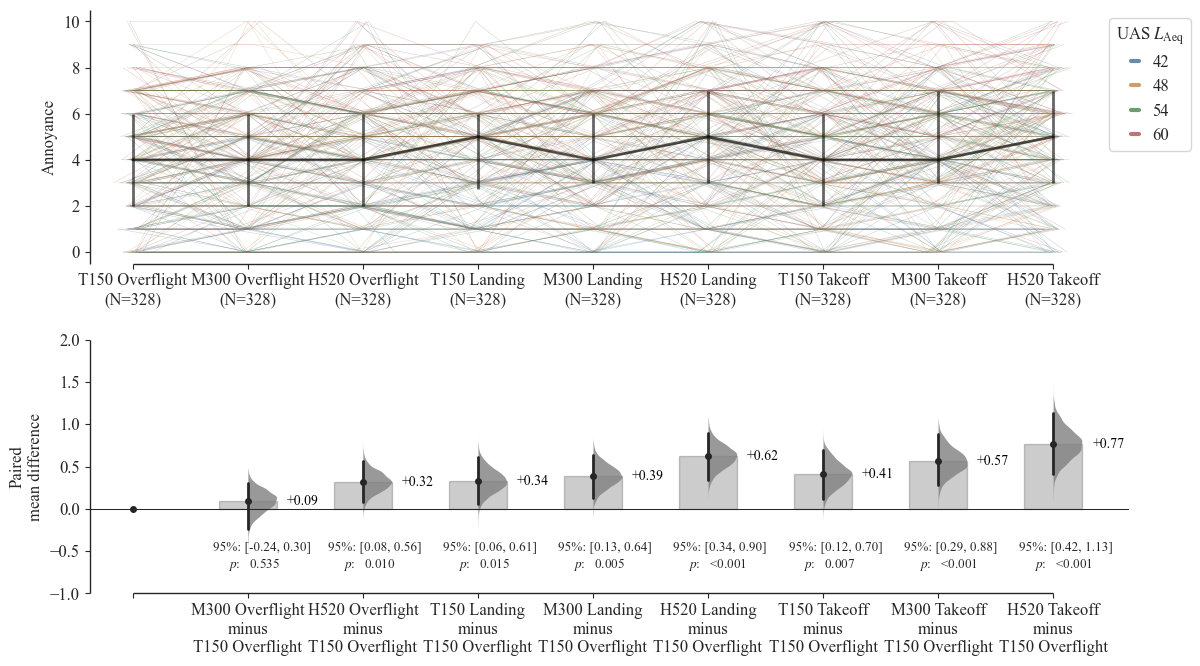

In [41]:
##### calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(12, 3.5))
dataMD = dataloadBL.mean_diff.plot(contrast_bars=True,
                                   group_summaries='median_quartiles',
                                   raw_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                   delta_dot=False,
                                   slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                   contrast_marker_size=4, contrast_ylim=(-1, 2), float_contrast=True,
                                   contrast_paired_lines=False,
                                   delta_text=True,
                                   legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                  'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=-0.5, s="95%: [" + ", ".join(vals) + "]", fontsize=9.5)
    contrast_ax.text(x=0.74 + ii + 0.09, y=-0.7, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=9.5)

lgd = ax.get_legend()
for lh in lgd.legend_handles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:

    filename = "PtATypeOpDabest"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests



In [42]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,T150 Overflight,M300 Overflight,328,328,41,Cohen's d,baseline,0.038661,95,-0.095916,0.127507,0.535493,1.659381e-01,10970.0,4.241502e-01,-0.800244
1,T150 Overflight,H520 Overflight,328,328,41,Cohen's d,baseline,0.130648,95,0.027164,0.234396,0.009798,2.803496e-03,10619.0,3.438486e-03,-2.947074
2,T150 Overflight,T150 Landing,328,328,41,Cohen's d,baseline,0.136109,95,0.020642,0.244590,0.014797,7.376186e-03,11421.5,1.140130e-02,-2.544547
3,T150 Overflight,M300 Landing,328,328,41,Cohen's d,baseline,0.160460,95,0.046174,0.268210,0.005199,3.304430e-04,11456.0,9.682409e-04,-3.329832
4,T150 Overflight,H520 Landing,328,328,41,Cohen's d,baseline,0.249409,95,0.131161,0.360371,0.000200,1.086049e-07,9182.5,1.814010e-06,-4.861293
5,T150 Overflight,T150 Takeoff,328,328,41,Cohen's d,baseline,0.164140,95,0.043934,0.273720,0.006599,7.971033e-04,11098.5,1.433034e-03,-3.215333
6,T150 Overflight,M300 Takeoff,328,328,41,Cohen's d,baseline,0.229319,95,0.109497,0.361558,0.000200,3.628993e-06,8409.0,5.337762e-06,-4.627711
7,T150 Overflight,H520 Takeoff,328,328,41,Cohen's d,baseline,0.311304,95,0.163930,0.459482,0.000200,1.918921e-08,10135.5,1.125239e-08,-5.860735


C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\2023533046.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\2023533046.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\2023533046.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,T150 Overflight,M300 Overflight,164,164,41,mean difference,baseline,0.280488,95,-0.048780,0.567073,0.073385,7.661721e-02,2611.5,1.005645e-01,-1.651487
1,T150 Overflight,H520 Overflight,164,164,41,mean difference,baseline,0.451220,95,0.103659,0.829268,0.013597,9.464494e-03,2706.5,7.273684e-03,-2.718222
2,T150 Overflight,T150 Landing,164,164,41,mean difference,baseline,0.615854,95,0.310976,1.000000,0.000400,1.621305e-03,2542.0,8.799697e-04,-3.388928
3,T150 Overflight,M300 Landing,164,164,41,mean difference,baseline,0.359756,95,0.042683,0.695122,0.039992,2.308370e-02,3187.5,3.248925e-02,-2.156767
4,T150 Overflight,H520 Landing,164,164,41,mean difference,baseline,0.817073,95,0.439024,1.231707,0.000200,2.140203e-05,2232.5,5.024485e-05,-4.165546
5,T150 Overflight,T150 Takeoff,164,164,41,mean difference,baseline,0.359756,95,0.000000,0.810976,0.100980,9.349323e-02,3320.5,6.650658e-02,-1.847367
6,T150 Overflight,M300 Takeoff,164,164,41,mean difference,baseline,0.609756,95,0.262195,0.981707,0.001800,5.676448e-04,2424.0,4.015446e-04,-3.613871
7,T150 Overflight,H520 Takeoff,164,164,41,mean difference,baseline,1.054878,95,0.621951,1.487805,0.000200,5.238470e-07,2117.5,1.629070e-07,-5.474587


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


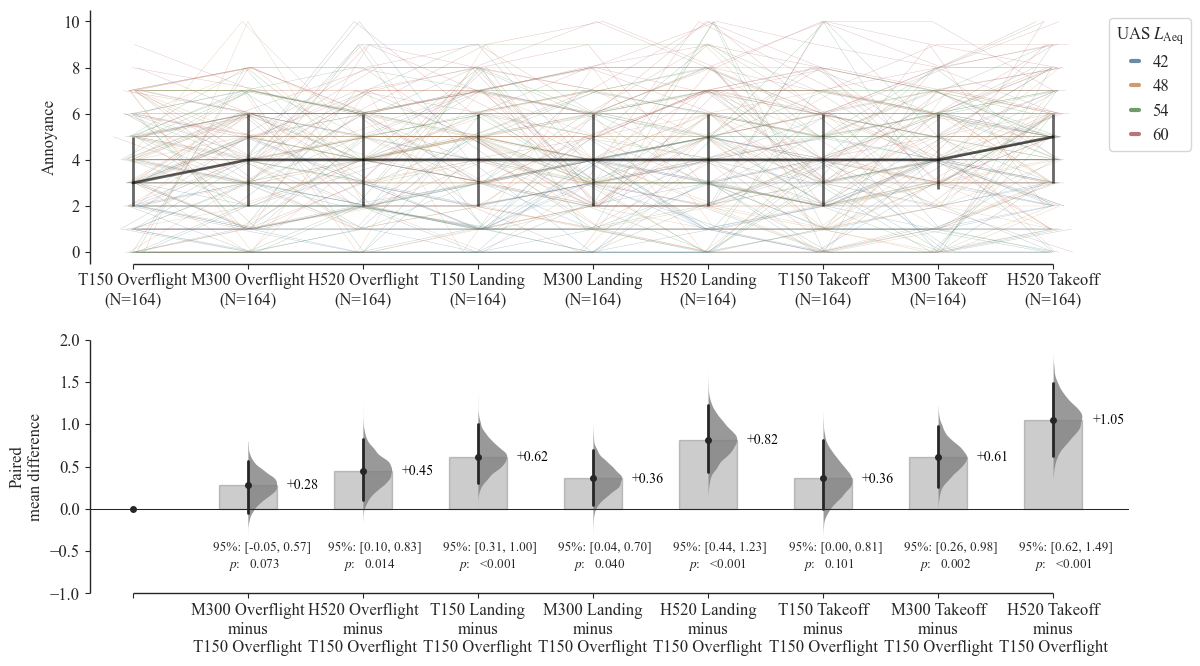

In [43]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(12, 3.5))
dataPkMD = dataPkloadBL.mean_diff.plot(contrast_bars=True,
                                       group_summaries='median_quartiles',
                                   raw_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                       delta_dot=False,
                                       slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                       contrast_marker_size=4, contrast_ylim=(-1, 2), float_contrast=True,
                                       contrast_paired_lines=False,
                                       delta_text=True,
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = dataPkloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=-0.5, s="95%: [" + ", ".join(vals) + "]", fontsize=9.5)
    contrast_ax.text(x=0.74 + ii + 0.09, y=-0.7, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=9.5)

lgd = ax.get_legend()
for lh in lgd.legend_handles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:

    filename = "PtAPkTypeOpDabest"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataPkMD;
dataPkloadBL.mean_diff.statistical_tests



In [44]:
out = pd.concat([out, dataPkloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataPkloadBL.cohens_d.statistical_tests])
dataPkloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,T150 Overflight,M300 Overflight,164,164,41,Cohen's d,baseline,0.118778,95,-0.021918,0.246498,0.073385,7.661721e-02,2611.5,1.005645e-01,-1.651487
1,T150 Overflight,H520 Overflight,164,164,41,Cohen's d,baseline,0.190719,95,0.043931,0.350858,0.013597,9.464494e-03,2706.5,7.273684e-03,-2.718222
2,T150 Overflight,T150 Landing,164,164,41,Cohen's d,baseline,0.255822,95,0.131589,0.413803,0.000400,1.621305e-03,2542.0,8.799697e-04,-3.388928
3,T150 Overflight,M300 Landing,164,164,41,Cohen's d,baseline,0.154951,95,0.021357,0.310574,0.039992,2.308370e-02,3187.5,3.248925e-02,-2.156767
4,T150 Overflight,H520 Landing,164,164,41,Cohen's d,baseline,0.326214,95,0.177555,0.487766,0.000200,2.140203e-05,2232.5,5.024485e-05,-4.165546
5,T150 Overflight,T150 Takeoff,164,164,41,Cohen's d,baseline,0.148812,95,0.000000,0.331489,0.100980,9.349323e-02,3320.5,6.650658e-02,-1.847367
6,T150 Overflight,M300 Takeoff,164,164,41,Cohen's d,baseline,0.260034,95,0.112019,0.426807,0.001400,5.676448e-04,2424.0,4.015446e-04,-3.613871
7,T150 Overflight,H520 Takeoff,164,164,41,Cohen's d,baseline,0.434757,95,0.253892,0.620380,0.000200,5.238470e-07,2117.5,1.629070e-07,-5.474587


C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\1821871526.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\1821871526.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\1821871526.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,T150 Overflight,M300 Overflight,164,164,41,mean difference,baseline,-0.091463,95,-0.640244,0.182927,0.714657,0.816491,2869.0,0.576389,0.559793
1,T150 Overflight,H520 Overflight,164,164,41,mean difference,baseline,0.195122,95,-0.140244,0.432927,0.199760,0.109890,2627.0,0.174730,-1.363102
2,T150 Overflight,T150 Landing,164,164,41,mean difference,baseline,0.054878,95,-0.451220,0.329268,0.784643,0.531751,3169.5,0.771865,-0.290419
3,T150 Overflight,M300 Landing,164,164,41,mean difference,baseline,0.426829,95,0.024390,0.737805,0.018996,0.005608,2597.5,0.011868,-2.544637
4,T150 Overflight,H520 Landing,164,164,41,mean difference,baseline,0.432927,95,-0.018293,0.713415,0.011598,0.001047,2366.5,0.009739,-2.615754
5,T150 Overflight,T150 Takeoff,164,164,41,mean difference,baseline,0.469512,95,0.042683,0.810976,0.017996,0.001750,2275.5,0.006284,-2.768487
6,T150 Overflight,M300 Takeoff,164,164,41,mean difference,baseline,0.524390,95,0.146341,0.902439,0.010598,0.001730,1812.0,0.003729,-2.942669
7,T150 Overflight,H520 Takeoff,164,164,41,mean difference,baseline,0.487805,95,0.060976,0.878049,0.025995,0.004959,3016.5,0.006565,-2.753513


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


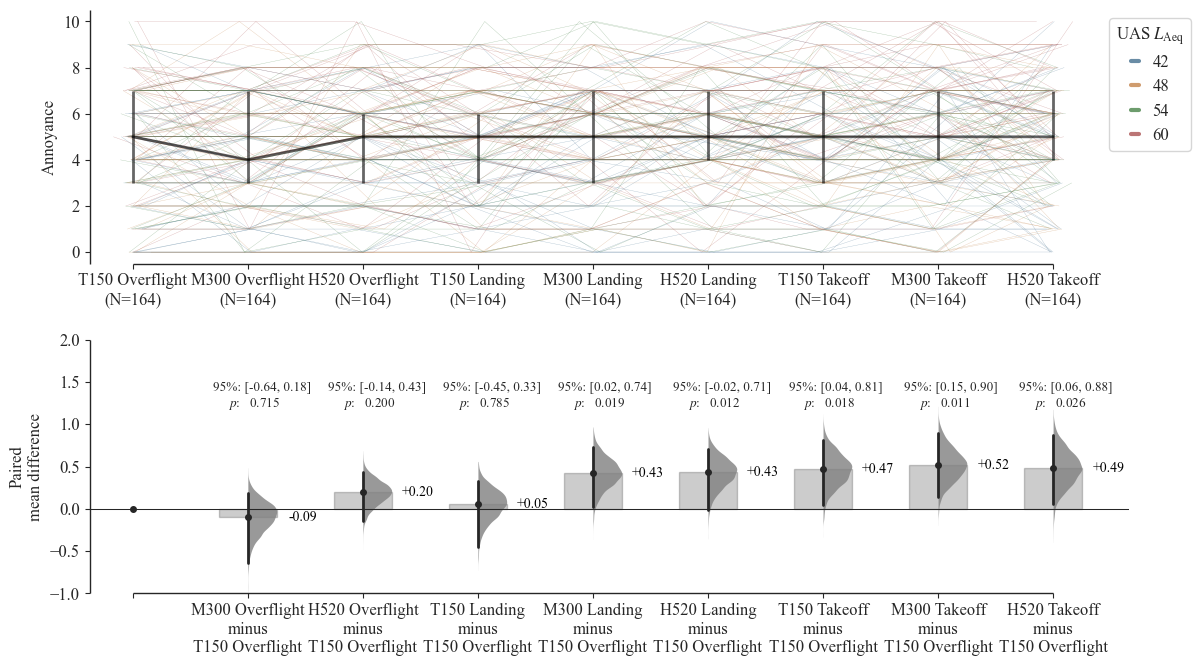

In [45]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(12, 3.5))
dataStMD = dataStloadBL.mean_diff.plot(contrast_bars=True,
                                       group_summaries='median_quartiles',
                                   raw_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                       delta_dot=False,
                                       slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                       contrast_marker_size=4, contrast_ylim=(-1, 2), float_contrast=True,
                                       contrast_paired_lines=False,
                                       delta_text=True,
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = dataStloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=1.4, s="95%: [" + ", ".join(vals) + "]", fontsize=9.5)
    contrast_ax.text(x=0.74 + ii + 0.09, y=1.2, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=9.5)

lgd = ax.get_legend()
for lh in lgd.legend_handles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:

    filename = "PtAStTypeOpDabest"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataStMD;
dataStloadBL.mean_diff.statistical_tests



In [46]:
out = pd.concat([out, dataStloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataStloadBL.cohens_d.statistical_tests])
dataStloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,T150 Overflight,M300 Overflight,164,164,41,Cohen's d,baseline,-0.037464,95,-0.251517,0.077963,0.714657,0.816491,2869.0,0.576389,0.559793
1,T150 Overflight,H520 Overflight,164,164,41,Cohen's d,baseline,0.078499,95,-0.054753,0.182882,0.199760,0.109890,2627.0,0.174730,-1.363102
2,T150 Overflight,T150 Landing,164,164,41,Cohen's d,baseline,0.022416,95,-0.181508,0.135374,0.784643,0.531751,3169.5,0.771865,-0.290419
3,T150 Overflight,M300 Landing,164,164,41,Cohen's d,baseline,0.174305,95,0.000000,0.306870,0.019396,0.005608,2597.5,0.011868,-2.544637
4,T150 Overflight,H520 Landing,164,164,41,Cohen's d,baseline,0.178591,95,-0.013023,0.302943,0.011598,0.001047,2366.5,0.009739,-2.615754
5,T150 Overflight,T150 Takeoff,164,164,41,Cohen's d,baseline,0.187563,95,0.012646,0.325100,0.017996,0.001750,2275.5,0.006284,-2.768487
6,T150 Overflight,M300 Takeoff,164,164,41,Cohen's d,baseline,0.210793,95,0.049746,0.362243,0.011598,0.001730,1812.0,0.003729,-2.942669
7,T150 Overflight,H520 Takeoff,164,164,41,Cohen's d,baseline,0.198481,95,0.018391,0.357158,0.025995,0.004959,3016.5,0.006565,-2.753513


 ## Part B



 ### Number of events

In [47]:
# select subset of data for analysis and sort
data = dataBySubjTestB
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASEvents', 'UASLAeq', 'UASType', 'Annoyance']]
data.sort_values(by=['ID', 'UASType', 'UASLAeq', 'UASEvents'], inplace=True)

dataLo = data.loc[data['UASLAeq'] == "54", :]
dataHi = data.loc[data['UASLAeq'] == "60", :]
dataH520 = data.loc[data['UASType'] == "H520", :]
dataT150 = data.loc[data['UASType'] == "T150", :]

# create dummy pairing ID for each participant to allow for paired analysis.
# Grouping by ID, UASType and UASLAeq works for every subset below: any
# column that's already constant within a given subset (e.g. UASType in
# dataH520) simply doesn't split the groups any further, so one grouping
# column list can safely be reused across all of them.
grouping_cols = ['ID', 'UASType', 'UASLAeq']

# ngroup() automatically assigns an identical integer to matching sets
# across the different UAS-events conditions
for dataset in [data, dataLo, dataHi, dataH520, dataT150]:
    # drop the "Baseline"/other-level categories by converting to plain string columns
    dataset['UASLAeq'] = dataset['UASLAeq'].astype(str)
    dataset['UASType'] = dataset['UASType'].astype(str)
    dataset['UASEvents'] = dataset['UASEvents'].astype(str)
    dataset['dummyID'] = dataset.groupby(grouping_cols).ngroup() + 1
    dataset.sort_values(by=['dummyID', 'ID', 'StimFile'], inplace=True)



In [48]:
# assign data for processing
dataloadBL = dabest.load(ps_adjust=True, data=data, idx=np.sort(data['UASEvents'].unique()),
                         x='UASEvents', y='Annoyance', paired='baseline',
                         id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=303)

dataloadSQ = dabest.load(ps_adjust=True, data=data, idx=np.sort(data['UASEvents'].unique()),
                         x='UASEvents', y='Annoyance', paired='sequential',
                         id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=303)

dataLoloadBL = dabest.load(ps_adjust=True, data=dataLo, idx=np.sort(dataLo['UASEvents'].unique()),
                           x='UASEvents', y='Annoyance', paired='baseline',
                           id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=303)

dataLoloadSQ = dabest.load(ps_adjust=True, data=dataLo, idx=np.sort(dataLo['UASEvents'].unique()),
                           x='UASEvents', y='Annoyance', paired='sequential',
                           id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=303)

dataHiloadSQ = dabest.load(ps_adjust=True, data=dataHi, idx=np.sort(dataHi['UASEvents'].unique()),
                           x='UASEvents', y='Annoyance', paired='sequential',
                           id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=303)

dataH520loadSQ = dabest.load(ps_adjust=True, data=dataH520, idx=np.sort(dataH520['UASEvents'].unique()),
                               x='UASEvents', y='Annoyance', paired='sequential',
                               id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=303)

dataT150loadSQ = dabest.load(ps_adjust=True, data=dataT150, idx=np.sort(dataT150['UASEvents'].unique()),
                               x='UASEvents', y='Annoyance', paired='sequential',
                               id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=303)


C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3769384943.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3769384943.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3769384943.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1.0,3.0,168,168,42,mean difference,baseline,0.976190,95,0.589286,1.375000,0.0002,3.991841e-08,1996.5,1.219659e-08,-5.994994
1,1.0,5.0,168,168,42,mean difference,baseline,1.273810,95,0.779762,1.803571,0.0002,2.049133e-11,1600.0,1.497806e-12,-7.652331
2,1.0,9.0,168,168,42,mean difference,baseline,1.410714,95,0.833333,2.059524,0.0002,1.248546e-10,2095.5,1.546221e-11,-7.241797


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


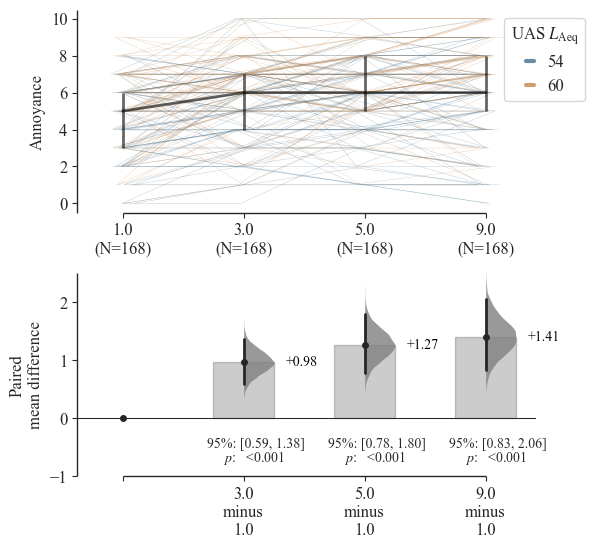

In [49]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(contrast_bars=True,
                                   group_summaries='median_quartiles',
                                   raw_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                   delta_dot=False,
                                   slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                   delta_text=True,
                                   contrast_marker_size=4, contrast_ylim=(-1, 2.5),
                                   contrast_paired_lines=False,
                                   legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                  'frameon': True, 'title_fontsize': 12}, ax=ax)

diffs = dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=-0.5, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.74 + ii + 0.09, y=-0.75, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legend_handles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:

    filename = "PtBDabestBase"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests



In [50]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1.0,3.0,168,168,42,Cohen's d,baseline,0.447704,95,0.251005,0.650017,0.0002,3.991841e-08,1996.5,1.219659e-08,-5.994994
1,1.0,5.0,168,168,42,Cohen's d,baseline,0.589221,95,0.351812,0.855676,0.0002,2.049133e-11,1600.0,1.497806e-12,-7.652331
2,1.0,9.0,168,168,42,Cohen's d,baseline,0.602227,95,0.338534,0.911542,0.0002,1.248546e-10,2095.5,1.546221e-11,-7.241797


C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3917413893.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3917413893.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3917413893.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1.0,3.0,168,168,42,mean difference,sequential,0.976190,95,0.589286,1.375000,0.000200,3.991841e-08,1996.5,1.219659e-08,-5.994994
1,3.0,5.0,168,168,42,mean difference,sequential,0.297619,95,-0.041667,0.571429,0.054589,1.094919e-02,2726.5,3.716497e-02,-2.100746
2,5.0,9.0,168,168,42,mean difference,sequential,0.136905,95,-0.107143,0.363095,0.243151,1.185307e-01,2741.5,2.422649e-01,-1.173503


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


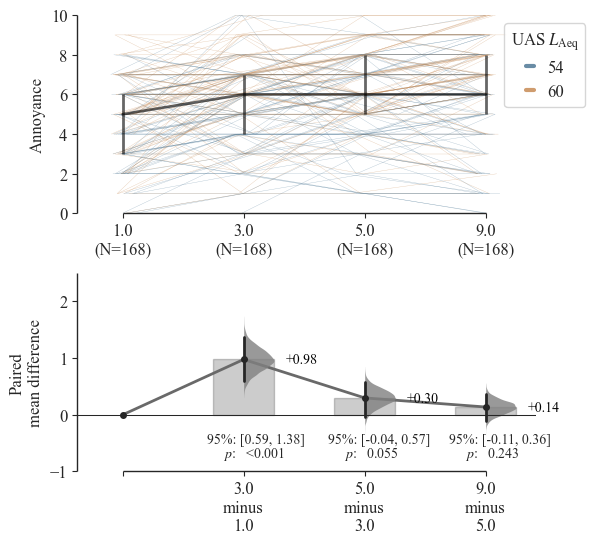

In [51]:
# calculate sequential paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadSQ.mean_diff.plot(contrast_bars=True,
                                   group_summaries='median_quartiles',
                                   raw_ylim=(0, 10), color_col='UASLAeq',
                                   delta_dot=False,
                                   slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                   delta_text=True,
                                   contrast_marker_size=4, contrast_ylim=(-1, 2.5),
                                   legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                  'frameon': True, 'title_fontsize': 12}, ax=ax)

diffs = dataloadSQ.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=-0.5, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.74 + ii + 0.09, y=-0.75, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legend_handles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)
    
if saveplots:

    filename = "PtBDabestSeq"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadSQ.mean_diff.statistical_tests



In [52]:
out = pd.concat([out, dataloadSQ.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadSQ.cohens_d.statistical_tests])
dataloadSQ.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1.0,3.0,168,168,42,Cohen's d,sequential,0.447704,95,0.251005,0.650017,0.000200,3.991841e-08,1996.5,1.219659e-08,-5.994994
1,3.0,5.0,168,168,42,Cohen's d,sequential,0.137169,95,-0.020349,0.270928,0.054589,1.094919e-02,2726.5,3.716497e-02,-2.100746
2,5.0,9.0,168,168,42,Cohen's d,sequential,0.058694,95,-0.044471,0.173166,0.243151,1.185307e-01,2741.5,2.422649e-01,-1.173503


 #### Segregated by LAeq



 ##### 54 dB

C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\761644290.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\761644290.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\761644290.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1.0,3.0,84,84,42,mean difference,sequential,0.821429,95,0.392857,1.261905,0.001000,0.000180,489.5,0.000131,-4.011605
1,3.0,5.0,84,84,42,mean difference,sequential,0.345238,95,-0.178571,0.642857,0.102180,0.025336,640.0,0.084735,-1.744719
2,5.0,9.0,84,84,42,mean difference,sequential,-0.154762,95,-0.476190,0.142857,0.369326,0.571022,730.5,0.357431,0.925420


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


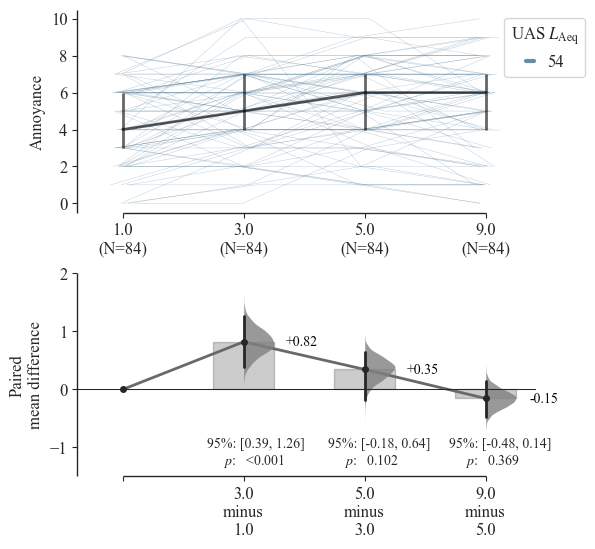

In [53]:
# calculate sequential paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataLoMD = dataLoloadSQ.mean_diff.plot(contrast_bars=True,
                                       group_summaries='median_quartiles',
                                   raw_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                       delta_dot=False,
                                       slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                       delta_text=True,
                                       contrast_marker_size=4, contrast_ylim=(-1.5, 2),
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)

diffs = dataLoloadSQ.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=-1, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.74 + ii + 0.09, y=-1.3, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legend_handles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:

    filename = "PtB54DabestSeq"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataLoMD;
dataLoloadSQ.mean_diff.statistical_tests



In [54]:
out = pd.concat([out, dataLoloadSQ.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataLoloadSQ.cohens_d.statistical_tests])
dataLoloadSQ.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1.0,3.0,84,84,42,Cohen's d,sequential,0.384312,95,0.174847,0.605680,0.001000,0.000180,489.5,0.000131,-4.011605
1,3.0,5.0,84,84,42,Cohen's d,sequential,0.159297,95,-0.077210,0.317925,0.102180,0.025336,640.0,0.084735,-1.744719
2,5.0,9.0,84,84,42,Cohen's d,sequential,-0.066582,95,-0.198977,0.075850,0.369326,0.571022,730.5,0.357431,0.925420


 ##### 60 dB

C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\375903625.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\375903625.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\375903625.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1.0,3.0,84,84,42,mean difference,sequential,1.130952,95,0.535714,1.690476,0.000200,0.000061,521.5,0.000025,-4.463727
1,3.0,5.0,84,84,42,mean difference,sequential,0.250000,95,-0.178571,0.654762,0.219956,0.158162,727.5,0.223543,-1.226329
2,5.0,9.0,84,84,42,mean difference,sequential,0.428571,95,0.095238,0.750000,0.019196,0.005573,508.0,0.007861,-2.724065


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


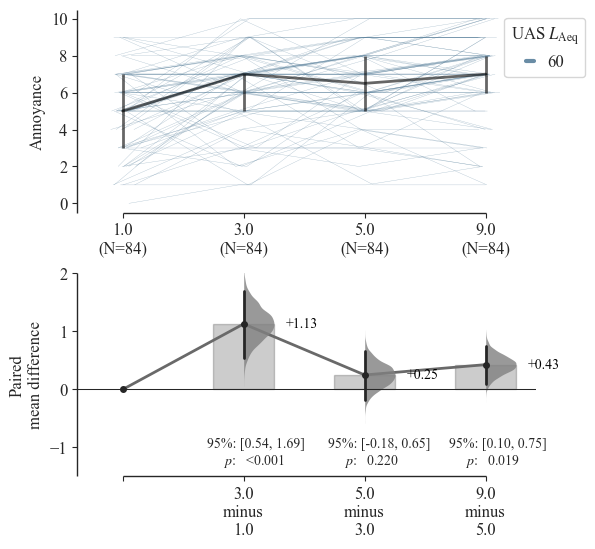

In [55]:
# calculate sequential paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataHiMD = dataHiloadSQ.mean_diff.plot(contrast_bars=True,
                                       group_summaries='median_quartiles',
                                   raw_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                       delta_dot=False,
                                       slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                       delta_text=True,
                                       contrast_marker_size=4, contrast_ylim=(-1.5, 2),
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)


diffs = dataHiloadSQ.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=-1, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.74 + ii + 0.09, y=-1.3, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legend_handles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:

    filename = "PtB60DabestSeq"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataHiMD;
dataHiloadSQ.mean_diff.statistical_tests



In [56]:
out = pd.concat([out, dataHiloadSQ.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataHiloadSQ.cohens_d.statistical_tests])
dataHiloadSQ.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1.0,3.0,84,84,42,Cohen's d,sequential,0.530258,95,0.235195,0.816457,0.000200,0.000061,521.5,0.000025,-4.463727
1,3.0,5.0,84,84,42,Cohen's d,sequential,0.121538,95,-0.089151,0.318173,0.220156,0.158162,727.5,0.223543,-1.226329
2,5.0,9.0,84,84,42,Cohen's d,sequential,0.198268,95,0.036346,0.396974,0.019196,0.005573,508.0,0.007861,-2.724065


 #### Segregated by UAS type



 ##### H520

C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3106952641.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3106952641.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3106952641.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1.0,3.0,84,84,42,mean difference,sequential,0.821429,95,0.380952,1.250000,0.000800,0.000474,523.5,0.000406,-3.685605
1,3.0,5.0,84,84,42,mean difference,sequential,0.416667,95,0.035714,0.785714,0.027794,0.029518,721.0,0.033319,-2.164249
2,5.0,9.0,84,84,42,mean difference,sequential,0.273810,95,-0.011905,0.523810,0.042392,0.048482,586.0,0.064330,-1.874858


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


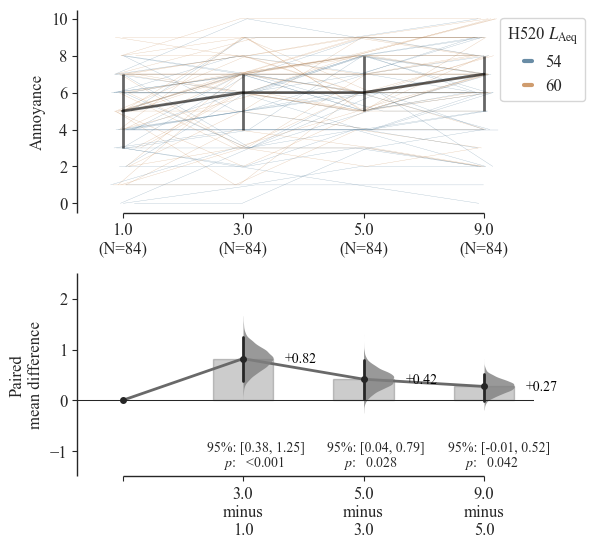

In [57]:
# calculate sequential paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataH520MD = dataH520loadSQ.mean_diff.plot(contrast_bars=True,
                                           group_summaries='median_quartiles',
                                            raw_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                               delta_dot=False,
                                               slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                               delta_text=True,
                                               contrast_marker_size=4, contrast_ylim=(-1.5, 2.5),
                                               legend_kwargs={'loc': 'upper center', 'title': r"H520 $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                              'frameon': True, 'title_fontsize': 12}, ax=ax)

diffs = dataH520loadSQ.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=-1, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.74 + ii + 0.09, y=-1.3, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legend_handles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:

    filename = "PtBH520DabestSeq"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataH520MD;
dataH520loadSQ.mean_diff.statistical_tests



In [58]:
out = pd.concat([out, dataH520loadSQ.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataH520loadSQ.cohens_d.statistical_tests])
dataH520loadSQ.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1.0,3.0,84,84,42,Cohen's d,sequential,0.360753,95,0.156255,0.579390,0.000800,0.000474,523.5,0.000406,-3.685605
1,3.0,5.0,84,84,42,Cohen's d,sequential,0.189972,95,0.018149,0.360530,0.027794,0.029518,721.0,0.033319,-2.164249
2,5.0,9.0,84,84,42,Cohen's d,sequential,0.122855,95,0.000000,0.257537,0.042392,0.048482,586.0,0.064330,-1.874858


 ##### T150

C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\2664644133.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\2664644133.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\2664644133.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1.0,3.0,84,84,42,mean difference,sequential,1.130952,95,0.654762,1.666667,0.000400,0.000021,484.0,0.000008,-4.760119
1,3.0,5.0,84,84,42,mean difference,sequential,0.178571,95,-0.416667,0.559524,0.440112,0.152560,650.0,0.393614,-0.857544
2,5.0,9.0,84,84,42,mean difference,sequential,0.000000,95,-0.428571,0.357143,0.956009,0.765591,790.0,1.000000,0.000000


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


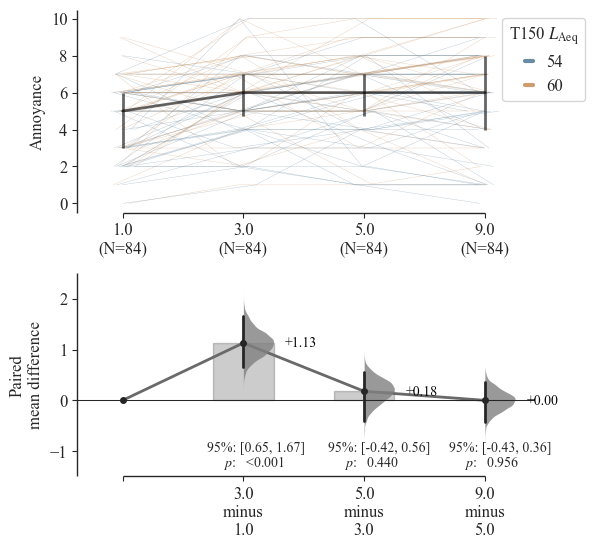

In [59]:
# calculate sequential paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataT150MD = dataT150loadSQ.mean_diff.plot(contrast_bars=True,
                                           group_summaries='median_quartiles',
                                   raw_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                               delta_dot=False,
                                               slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45, 'jitter': 0.3},
                                               delta_text=True,
                                               contrast_marker_size=4, contrast_ylim=(-1.5, 2.5),
                                               legend_kwargs={'loc': 'upper center', 'title': r"T150 $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                              'frameon': True, 'title_fontsize': 12}, ax=ax)

diffs = dataT150loadSQ.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=-1, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.74 + ii + 0.09, y=-1.3, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legend_handles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:

    filename = "PtBT150DabestSeq"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataT150MD;
dataT150loadSQ.mean_diff.statistical_tests



In [60]:
out = pd.concat([out, dataT150loadSQ.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataT150loadSQ.cohens_d.statistical_tests])
dataT150loadSQ.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1.0,3.0,84,84,42,Cohen's d,sequential,0.541703,95,0.303933,0.815287,0.000400,0.000021,484.0,0.000008,-4.760119
1,3.0,5.0,84,84,42,Cohen's d,sequential,0.082824,95,-0.192208,0.270992,0.440112,0.152560,650.0,0.393614,-0.857544
2,5.0,9.0,84,84,42,Cohen's d,sequential,0.000000,95,-0.172382,0.160274,0.956009,0.765591,790.0,1.000000,0.000000


 ## Parts A and B combined



 ### AAM attitude

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTest.copy()
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'AAM_attitude', 'Annoyance']]

# assign data for processing
dataloadBL = dabest.load(ps_adjust=True, data=data, idx=['Supportive', 'Ambivalent', 'Concerned', 'Neutral'],
                         x='AAM_attitude', y='Annoyance', cluster_col='ID', resamples=5000, random_seed=303)


IndexError: "Ambivalent" is not a group in the column `AAM_attitude`. Please check `idx` and try again.

C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3192832566.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3192832566.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3192832566.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Supportive,Ambivalent,1034,768,20,mean difference,None,0.795261,95,-0.424328,2.160718,0.295938,8.029949e-12,-6.884668,2.165023e-11,-6.737269,6.909585e-11,326288.0
1,Supportive,Concerned,1034,658,18,mean difference,None,0.657917,95,-0.952888,2.047527,0.439296,7.900013e-08,-5.395853,1.695260e-07,-5.251998,3.037012e-07,290326.5
2,Supportive,Neutral,1034,1410,26,mean difference,None,1.339781,95,0.227273,2.625854,0.036393,6.911693e-36,-12.737735,1.431297e-36,-12.841101,2.165400e-32,525950.5


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


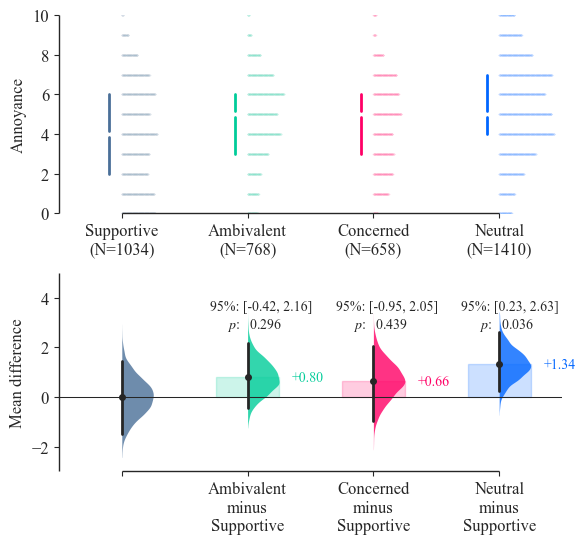

In [ ]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(raw_bars=False,
                                   contrast_bars=True,
                                   group_summaries='median_quartiles',
                                   show_baseline_ec=True,
                                   raw_ylim=(0, 10),
                                   raw_marker_size=0.004,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   delta_text=True,
                                   custom_palette={'Neutral': mycolours[0],
                                                   'Ambivalent': mycolours[1],
                                                   'Concerned': mycolours[2],
                                                   'Supportive': mycolours[3]},
                                   raw_desat=1,
                                   contrast_desat=1,
                                   contrast_marker_size=4,
                                   contrast_ylim=(-3, 5),
                                   ax=ax,
                                  )

diffs = dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=4, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.84 + ii, y=3.3, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

if saveplots:

    filename = "PtsABAttDabestBase"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')


dataMD;
dataloadBL.mean_diff.statistical_tests



In [63]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Supportive,Ambivalent,1034,768,20,Cohen's d,None,0.320937,95,-0.185619,0.923965,0.296138,8.029949e-12,-6.884668,2.165023e-11,-6.737269,6.909585e-11,326288.0
1,Supportive,Concerned,1034,658,18,Cohen's d,None,0.261910,95,-0.422846,0.837164,0.439896,7.900013e-08,-5.395853,1.695260e-07,-5.251998,3.037012e-07,290326.5
2,Supportive,Neutral,1034,1410,26,Cohen's d,None,0.525755,95,0.070837,1.042598,0.036793,6.911693e-36,-12.737735,1.431297e-36,-12.841101,2.165400e-32,525950.5


#### Combine all non-supportive categories into one

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTest.copy()
data.loc[(data['AAM_attitude'] != "Supportive"), 'AAM_attitude'] = "Ambiv_Concern_Neutral"
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'AAM_attitude', 'Annoyance']]

# assign data for processing
dataloadBL = dabest.load(ps_adjust=True, data=data, idx=['Supportive', 'Ambiv_Concern_Neutral'],
                         x='AAM_attitude', y='Annoyance', cluster_col='ID', resamples=5000, random_seed=999)


C:\Users\m_lot\repos\DABEST-python-cluster\dabest\plot_tools.py:2593: UserWarning: 5.1% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Supportive,Ambiv_Concern_Neutral,1034,2836,42,mean difference,None,1.034119,95,0.019935,2.293477,0.05199,1.369884e-27,-11.077462,3.145041e-30,-11.522583,3.225088e-26,1142565.0


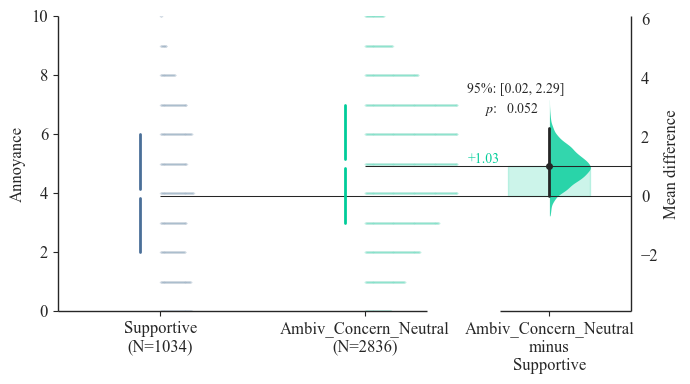

In [116]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(7, 4))
dataMD = dataloadBL.mean_diff.plot(raw_bars=False,
                                   contrast_bars=True,
                                   group_summaries='median_quartiles',
                                   show_baseline_ec=True,
                                   raw_ylim=(0, 10),
                                   raw_marker_size=0.004,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   delta_text=True,
                                   custom_palette={'Supportive': mycolours[3],
                                                   'Ambiv_Concern_Neutral': mycolours[1]},
                                   raw_desat=1,
                                   contrast_desat=1,
                                   contrast_marker_size=4,
                                   ax=ax,
                                  )

diffs = dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.5 + ii, y=3.5, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.6 + ii, y=2.8, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

if saveplots:

    filename = "PtsABAtt2DabestBase"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')


dataMD;
dataloadBL.mean_diff.statistical_tests



In [ ]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Supportive,Ambivalent,1034,768,20,Cohen's d,None,0.320937,95,-0.185619,0.923965,0.296138,8.029949e-12,-6.884668,2.165023e-11,-6.737269,6.909585e-11,326288.0
1,Supportive,Concerned,1034,658,18,Cohen's d,None,0.261910,95,-0.422846,0.837164,0.439896,7.900013e-08,-5.395853,1.695260e-07,-5.251998,3.037012e-07,290326.5
2,Supportive,Neutral,1034,1410,26,Cohen's d,None,0.525755,95,0.070837,1.042598,0.036793,6.911693e-36,-12.737735,1.431297e-36,-12.841101,2.165400e-32,525950.5


##### High annoyance

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTest.copy()
data.loc[(data['AAM_attitude'] != "Supportive"), 'AAM_attitude'] = "Ambiv_Concern_Neutral"
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'AAM_attitude', 'HighAnnoy']]

# assign data for processing
dataloadBL = dabest.load(ps_adjust=True, data=data, idx=['Supportive', 'Ambiv_Concern_Neutral'],
                         proportional=True, x='AAM_attitude', y='HighAnnoy',
                         cluster_col='ID', resamples=5000, random_seed=999)


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation
0,Supportive,Ambiv_Concern_Neutral,1034,2836,42,mean difference,None,0.052865,95,-0.018469,0.122918,0.235


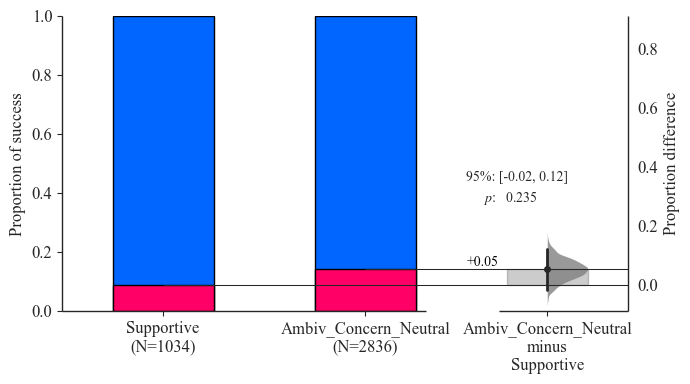

In [ ]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(7, 4))
dataMD = dataloadBL.mean_diff.plot(raw_bars=True,
                                   contrast_bars=True,
                                   group_summaries='median_quartiles',
                                   raw_ylim=(0, 1),
                                   delta_text=True,
                                   custom_palette={1: mycolours[2],
                                                   0: mycolours[0]},
                                   raw_desat=1,
                                   contrast_desat=1,
                                   contrast_marker_size=4,
                                   ax=ax,
                                  )

diffs = dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.5 + ii, y=0.35, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.6 + ii, y=0.28, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

ax.set_ylabel("Highly annoyed", fontsize=12)

if saveplots:

    filename = "PtsABAtt2HiAnnoyDabestBase"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')


dataMD;
dataloadBL.mean_diff.statistical_tests



 ### Home residence area

In [64]:
# select subset of data for analysis and sort
data = dataBySubjTest
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASLAeq', 'Home_Area', 'Annoyance']]

# assign data for processing
dataloadBL = dabest.load(ps_adjust=True, data=data, idx=['Urban', 'Suburban', 'Rural'],
                         x='Home_Area', y='Annoyance', cluster_col='ID', resamples=5000, random_seed=303)



C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3069195074.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3069195074.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3069195074.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Urban,Suburban,2538,1238,41,mean difference,None,0.798491,95,0.096126,1.491262,0.124575,5.121281e-23,-9.962372,2.599062e-20,-9.287360,3.998285e-17,1308218.0
1,Urban,Rural,2538,94,28,mean difference,None,-0.021277,95,-0.704492,0.656028,0.933733,9.397852e-01,0.075730,9.386525e-01,0.076971,8.717717e-01,120447.5


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


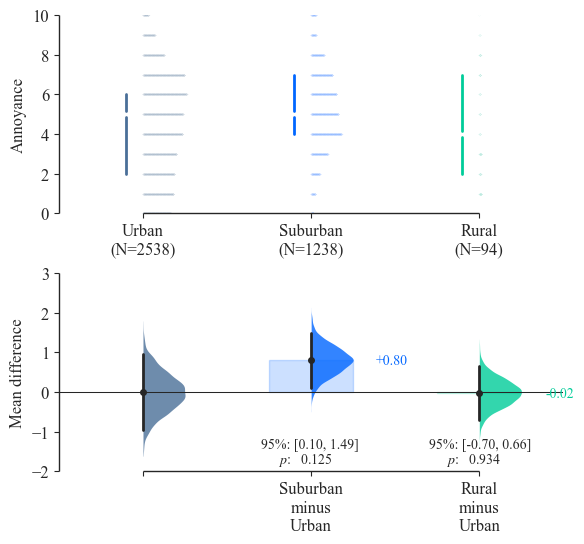

In [65]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(raw_bars=False,
                                   contrast_bars=True,
                                   group_summaries='median_quartiles',
                                   show_baseline_ec=True,
                                   raw_ylim=(0, 10),
                                   raw_marker_size=0.001,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   delta_dot_kwargs={'size': 1, 'side': 'left', 'alpha': 0.25, 'zorder': 1},
                                   delta_text=True,
                                   custom_palette={'Suburban': mycolours[0],
                                                   'Rural': mycolours[1],
                                                   'Urban': mycolours[3]},
                                   raw_desat=1,
                                   contrast_desat=1,
                                   contrast_marker_size=4,
                                   contrast_ylim=(-2, 3),
                                   ax=ax,
                                   )

diffs = dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=-1.4, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.8 + ii, y=-1.8, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

if saveplots:

    filename = "PtsABAORDabestBase"
    
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests



In [66]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Urban,Suburban,2538,1238,41,Cohen's d,None,0.321960,95,0.035615,0.602319,0.124575,5.121281e-23,-9.962372,2.599062e-20,-9.287360,3.998285e-17,1308218.0
1,Urban,Rural,2538,94,28,Cohen's d,None,-0.008085,95,-0.284853,0.249790,0.964277,9.397852e-01,0.075730,9.386525e-01,0.076971,8.717717e-01,120447.5


 ### Area soundscape character

In [67]:
# select subset of data for analysis and sort
data = dataBySubjTest
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'Area_soundscape', 'Annoyance']]

# assign data for processing
dataloadBL = dabest.load(ps_adjust=True, data=data, idx=['Monotonous', 'Calm', 'Chaotic', 'Vibrant'],
                         x='Area_soundscape', y='Annoyance', cluster_col='ID', resamples=5000, random_seed=303)



C:\Users\m_lot\repos\DABEST-python-cluster\dabest\plot_tools.py:2593: UserWarning: 1.0% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\174296222.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtsABScapeDabestBase.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\174296222.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtsABScapeDabestBase.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\174296222.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtsABScapeDabest

,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Monotonous,Calm,376,1880,24,mean difference,None,0.154787,95,-0.769681,1.546277,0.813990,0.256800,-1.135209,0.252224,-1.145258,2.000882e-01,338777.0
1,Monotonous,Chaotic,376,376,8,mean difference,None,0.430851,95,-2.276596,2.087766,0.609017,0.020444,-2.323075,0.020442,-2.323075,2.244985e-03,61651.0
2,Monotonous,Vibrant,376,1238,18,mean difference,None,0.688692,95,-0.539134,2.220084,0.513534,0.000003,-4.732668,0.000007,-4.520023,9.778189e-07,194234.0


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


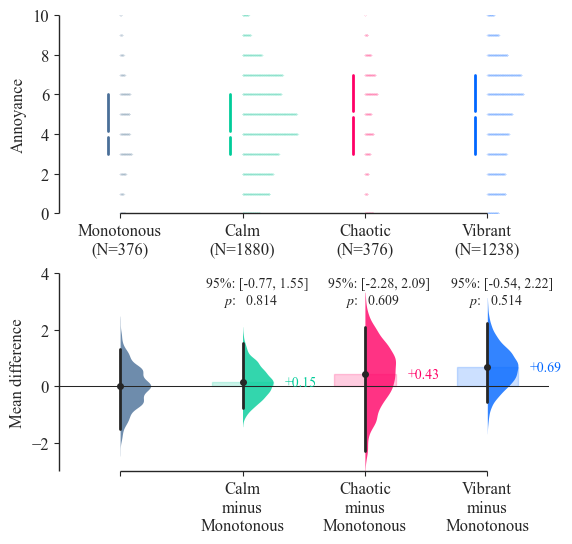

In [68]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(raw_bars=False,
                                   contrast_bars=True,
                                   group_summaries='median_quartiles',
                                   show_baseline_ec=True,
                                   raw_ylim=(0, 10),
                                   raw_marker_size=0.002,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   delta_dot_kwargs={'size': 1, 'side': 'left', 'alpha': 0.25, 'zorder': 1},
                                   delta_text=True,
                                   custom_palette={'Monotonous': mycolours[3],
                                                   'Calm': mycolours[1],
                                                   'Chaotic': mycolours[2],
                                                   'Vibrant': mycolours[0]},
                                   raw_desat=1,
                                   contrast_desat=1,
                                   contrast_marker_size=4,
                                   contrast_ylim=(-3, 4),
                                   ax=ax,
                                   )

diffs = dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=3.5, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.84 + ii, y=2.9, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtsABScapeDabestBase.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtsABScapeDabestBase.pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests



In [69]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Monotonous,Calm,376,1880,24,Cohen's d,None,0.064699,95,-0.325378,0.657956,0.813990,0.256800,-1.135209,0.252224,-1.145258,2.000882e-01,338777.0
1,Monotonous,Chaotic,376,376,8,Cohen's d,None,0.169428,95,-0.994737,0.920155,0.681212,0.020444,-2.323075,0.020442,-2.323075,2.244985e-03,61651.0
2,Monotonous,Vibrant,376,1238,18,Cohen's d,None,0.266157,95,-0.231305,0.898954,0.513734,0.000003,-4.732668,0.000007,-4.520023,9.778189e-07,194234.0


 ### Nationality region

In [70]:
# select subset of data for analysis and sort
data = dataBySubjTest
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASLAeq', 'NationGeo', 'Annoyance']]



In [71]:
# assign data for processing
dataloadBL = dabest.load(ps_adjust=True, data=data, idx=['UK', 'Africa', 'EastAsia', 'MidEast', 'SouthAsia', 'Europe', 'SouthAmerica', 'Australasia'],
                         x='NationGeo', y='Annoyance', cluster_col='ID', resamples=5000, random_seed=303)



C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\4109041273.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\4109041273.py:42: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\4109041273.py:42: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Africa,1708,752,27,mean difference,None,-1.216223,95,-2.396207,0.314478,0.068386,4.970285e-26,10.776461,6.295599e-28,11.091125,9.463814e-26,811401.5
1,UK,EastAsia,1708,376,23,mean difference,None,0.438033,95,-0.907055,1.658035,0.616020,1.663058e-03,-3.160110,1.674955e-03,-3.146637,3.369082e-03,290350.0
2,UK,MidEast,1708,282,22,mean difference,None,1.313033,95,0.521646,2.171359,0.091257,3.884421e-19,-9.395614,3.732686e-17,-8.497746,7.427490e-19,162126.5
3,UK,SouthAsia,1708,188,21,mean difference,None,-0.910372,95,-1.691489,-0.003774,0.387541,8.467463e-10,6.361590,7.759408e-07,4.957950,6.296411e-08,198811.5
4,UK,Europe,1708,94,20,mean difference,None,0.621543,95,0.115901,1.367301,0.473591,1.329701e-03,-3.290645,1.523101e-02,-2.429163,2.134054e-02,69053.0
5,UK,SouthAmerica,1708,94,20,mean difference,None,2.919416,95,2.413774,3.665174,0.065600,5.121429e-23,-12.679337,8.725824e-29,-11.328408,8.778196e-26,29055.0
6,UK,Australasia,1708,94,20,mean difference,None,1.610905,95,1.105263,2.356663,0.173309,1.886095e-14,-8.762659,3.714025e-10,-6.300797,5.720153e-11,48333.0


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


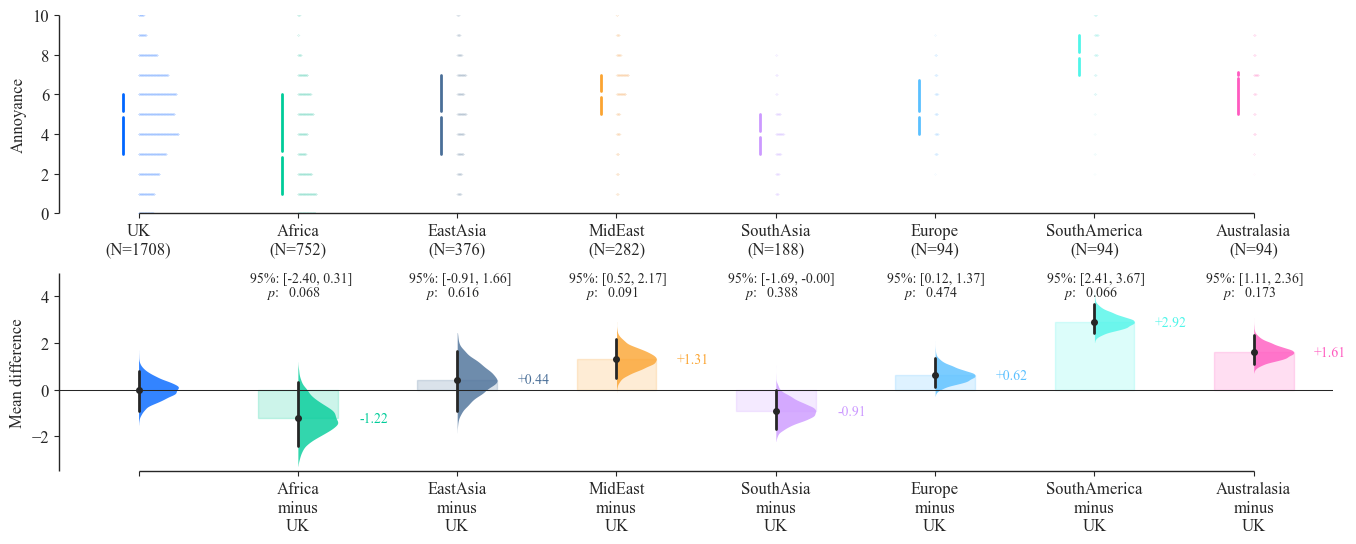

In [72]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(13.71, 3))
dataMD = dataloadBL.mean_diff.plot(raw_bars=False,
                                   contrast_bars=True,
                                   group_summaries='median_quartiles',
                                   show_baseline_ec=True,
                                   raw_ylim=(0, 10),
                                   raw_marker_size=0.001,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   delta_dot_kwargs={'size': 1, 'side': 'left', 'alpha': 0.25, 'zorder': 1},
                                   delta_text=True,
                                   custom_palette={'UK': mycolours[0],
                                                   'Africa': mycolours[1],
                                                   'EastAsia': mycolours[3],
                                                   'MidEast': mycolours[4],
                                                   'SouthAsia': mycolours[5],
                                                   'Europe': mycolours[6],
                                                   'SouthAmerica': mycolours[7],
                                                   'Australasia': mycolours[8]},
                                   raw_desat=1,
                                   contrast_desat=1,
                                   contrast_marker_size=4,
                                   contrast_ylim=(-3.5, 5),
                                   ax=ax,
                                   )

diffs = dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=4.6, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.8 + ii, y=4, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)


if saveplots:

    filename = "PtsABNationDabestBase"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests



In [ ]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
dataloadBL.cohens_d.statistical_tests
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Africa,1708,752,27,Cohen's d,None,-0.485389,95,-1.012782,0.133681,0.068786,4.970285e-26,10.776461,6.295599e-28,11.091125,9.463814e-26,811401.5
1,UK,EastAsia,1708,376,23,Cohen's d,None,0.179249,95,-0.400154,0.655615,0.618420,1.663058e-03,-3.160110,1.674955e-03,-3.146637,3.369082e-03,290350.0
2,UK,MidEast,1708,282,22,Cohen's d,None,0.546213,95,0.212691,0.876436,0.093657,3.884421e-19,-9.395614,3.732686e-17,-8.497746,7.427490e-19,162126.5
3,UK,SouthAsia,1708,188,21,Cohen's d,None,-0.380977,95,-0.771601,0.004847,0.391340,8.467463e-10,6.361590,7.759408e-07,4.957950,6.296411e-08,198811.5
4,UK,Europe,1708,94,20,Cohen's d,None,0.257351,95,0.049672,0.533004,0.514478,1.329701e-03,-3.290645,1.523101e-02,-2.429163,2.134054e-02,69053.0
5,UK,SouthAmerica,1708,94,20,Cohen's d,None,1.200158,95,1.037295,1.411471,0.106892,5.121429e-23,-12.679337,8.725824e-29,-11.328408,8.778196e-26,29055.0
6,UK,Australasia,1708,94,20,Cohen's d,None,0.667521,95,0.487186,0.911001,0.213132,1.886095e-14,-8.762659,3.714025e-10,-6.300797,5.720153e-11,48333.0


 #### Combining all non-UK regions into one 'other' group

In [74]:
# create new subset of data for analysis and sort
data = dataBySubjTest.copy()
data.loc[(data['NationGeo'] != "UK") & ~data['NationGeo'].isna(), 'NationGeo'] = "Other"
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASLAeq', 'NationGeo', 'Annoyance']]



In [75]:
# assign data for processing
dataloadBL = dabest.load(ps_adjust=True, data=data, idx=['UK', 'Other'],
                         x='NationGeo', y='Annoyance', cluster_col='ID', resamples=5000, random_seed=303)



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Other,1708,1880,39,mean difference,None,-0.035372,95,-0.917113,0.983623,0.95041,0.67756,0.415828,0.678713,0.414254,0.906672,1609130.5


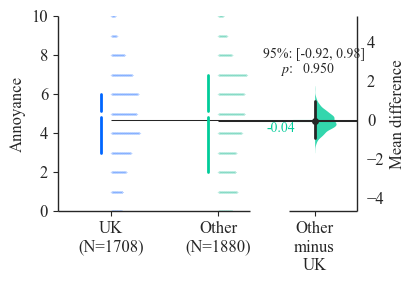

In [76]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(4.29, 3))
dataMD = dataloadBL.mean_diff.plot(raw_bars=False,
                                   contrast_bars=True,
                                   group_summaries='median_quartiles',
                                   show_baseline_ec=True,
                                   raw_ylim=(0, 10),
                                   raw_marker_size=0.001,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   delta_dot_kwargs={'size': 1, 'side': 'left', 'alpha': 0.25, 'zorder': 1},
                                   delta_text=True,
                                   custom_palette={'UK': mycolours[0],
                                                   'Other': mycolours[1]},
                                   raw_desat=1,
                                   contrast_desat=1,
                                   contrast_marker_size=4,
                                   ax=ax,
                                   )

diffs = dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.4 + ii, y=3.2, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.6 + ii, y=2.4, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

if saveplots:

    filename = "PtsABNation2DabestBase"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')


dataMD;
dataloadBL.mean_diff.statistical_tests



In [77]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Other,1708,1880,39,Cohen's d,None,-0.013847,95,-0.366212,0.391138,0.95041,0.67756,0.415828,0.678713,0.414254,0.906672,1609130.5


 Combining all non-UK regions except Africa into one 'other' group

In [78]:
# create new subset of data for analysis and sort
data = dataBySubjTest.copy()
data.loc[(data['NationGeo'] != "UK") & (data['NationGeo'] != "Africa") & ~data['NationGeo'].isna(), 'NationGeo'] = "Other"
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASLAeq', 'NationGeo', 'Annoyance']]



In [79]:
# assign data for processing
dataloadBL = dabest.load(ps_adjust=True, data=data, idx=['UK', 'Africa', 'Other'],
                         x='NationGeo', y='Annoyance', cluster_col='ID', resamples=5000, random_seed=303)



C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\4024851586.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\4024851586.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\4024851586.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Africa,1708,752,27,mean difference,None,-1.216223,95,-2.396207,0.314478,0.068386,4.970285e-26,10.776461,6.295599e-28,11.091125,9.463814e-26,811401.5
1,UK,Other,1708,1128,31,mean difference,None,0.751862,95,-0.180519,1.708380,0.141172,3.649696e-16,-8.205360,5.984273e-16,-8.137288,5.524505e-15,797729.0


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


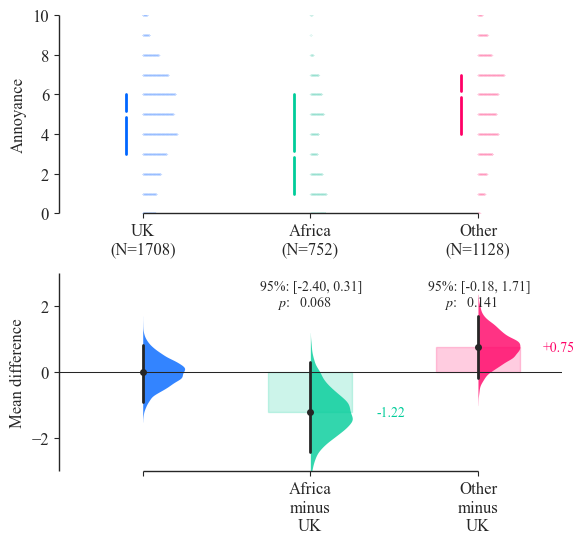

In [80]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(raw_bars=False,
                                   contrast_bars=True,
                                   group_summaries='median_quartiles',
                                   show_baseline_ec=True,
                                   raw_ylim=(0, 10),
                                   raw_marker_size=0.001,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   delta_dot_kwargs={'size': 1, 'side': 'left', 'alpha': 0.25, 'zorder': 1},
                                   delta_text=True,
                                   custom_palette={'UK': mycolours[0],
                                                   'Africa': mycolours[1],
                                                   'Other': mycolours[2]},
                                   raw_desat=1,
                                   contrast_desat=1,
                                   contrast_marker_size=4,
                                   contrast_ylim=(-3, 3),
                                   ax=ax,
                                   )

diffs = dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=2.5, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.8 + ii, y=2, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

if saveplots:

    filename = "PtsABNation3DabestBase"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests



In [81]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Africa,1708,752,27,Cohen's d,None,-0.485389,95,-1.012782,0.133681,0.068786,4.970285e-26,10.776461,6.295599e-28,11.091125,9.463814e-26,811401.5
1,UK,Other,1708,1128,31,Cohen's d,None,0.312201,95,-0.083930,0.695313,0.141172,3.649696e-16,-8.205360,5.984273e-16,-8.137288,5.524505e-15,797729.0


 #### Combine Africa and South Asia into one group

In [82]:
# create new subset of data for analysis and sort
data = dataBySubjTest.copy()
data.loc[(data['NationGeo'] == "Africa") | (data['NationGeo'] == "SouthAsia"), 'NationGeo'] = "Africa_SAsia"
data.loc[(data['NationGeo'] != "UK") & (data['NationGeo'] != "Africa_SAsia") & ~data['NationGeo'].isna(), 'NationGeo'] = "Other"
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASLAeq', 'NationGeo', 'Annoyance']]



In [83]:
# assign data for processing
dataloadBL = dabest.load(ps_adjust=True, data=data, idx=['UK', 'Africa_SAsia', 'Other'],
                         x='NationGeo', y='Annoyance', cluster_col='ID', resamples=5000, random_seed=303)


C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3486147973.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3486147973.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_27288\3486147973.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Africa_SAsia,1708,940,29,mean difference,None,-1.155053,95,-2.159574,0.152376,0.055189,1.349025e-29,11.490964,3.826047e-30,11.550551,1.373441e-28,1010213.0
1,UK,Other,1708,940,29,mean difference,None,1.084309,95,0.180179,2.052053,0.039992,7.108734e-29,-11.324787,3.594176e-28,-11.133752,1.083899e-27,598917.5


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


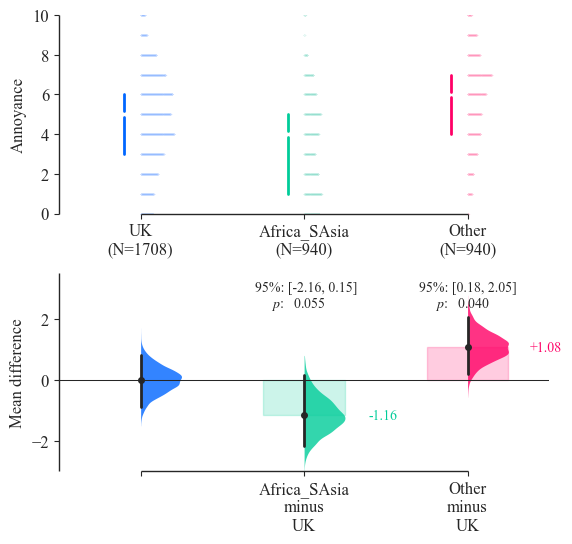

In [84]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(raw_bars=False,
                                   contrast_bars=True,
                                   group_summaries='median_quartiles',
                                   show_baseline_ec=True,
                                   raw_ylim=(0, 10),
                                   raw_marker_size=0.001,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   delta_dot_kwargs={'size': 1, 'side': 'left', 'alpha': 0.25, 'zorder': 1},
                                   delta_text=True,
                                   custom_palette={'UK': mycolours[0],
                                                   'Africa_SAsia': mycolours[1],
                                                   'Other': mycolours[2]},
                                   raw_desat=1,
                                   contrast_desat=1,
                                   contrast_marker_size=4,
                                   contrast_ylim=(-3, 3.5),
                                   ax=ax,
                                   )

diffs = dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high', 'pvalue_permutation']].values
# label results
contrast_ax = ax.contrast_axes
for ii, diff in enumerate(diffs):
    vals = display_round(diff[1:3], digits=2, floor=False)
    contrast_ax.text(x=0.7 + ii, y=2.9, s="95%: [" + ", ".join(vals) + "]", fontsize=10)
    contrast_ax.text(x=0.8  + ii, y=2.4, s=r"$p$:   " + display_round(diff[-1], digits=3), fontsize=10)

if saveplots:

    filename = "PtsABNation4DabestBase"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')


dataMD;
dataloadBL.mean_diff.statistical_tests



In [85]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests



,control,test,control_N,test_N,n_clusters,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Africa_SAsia,1708,940,29,Cohen's d,None,-0.469087,95,-0.920447,0.077532,0.055389,1.349025e-29,11.490964,3.826047e-30,11.550551,1.373441e-28,1010213.0
1,UK,Other,1708,940,29,Cohen's d,None,0.452161,95,0.054014,0.819986,0.039992,7.108734e-29,-11.324787,3.594176e-28,-11.133752,1.083899e-27,598917.5


 ## Save output data to file

In [86]:
if savedata:
    out.to_csv(os.path.join(outDataPath, "dabest_mean_diff.csv"))
    outd.to_csv(os.path.join(outDataPath, "dabest_cohens_d.csv"))


 # Comparison with DroneNoise data

In [87]:
dataDNoiseWideFilePath = list(QFileDialog.getOpenFileName(filter="DroneNoise2022AnnoyWide.csv",
                                                       caption=r"Open DroneNoise2022AnnoyWide.csv in: \03 Experiment\Experiment 1\Analysis\Comparison_data"))[0]

dataDNoiseWide = pd.read_csv(dataDNoiseWideFilePath)

dataDNoiseLong = dataDNoiseWide.melt(id_vars='ID', var_name='StimFile', value_name='Annoyance')
dataDNoiseLong.head()


,ID,StimFile,Annoyance
0,1,GD28X_Event-210_mic2_Fast_FO_Closed CAL.wav,0.9
1,2,GD28X_Event-210_mic2_Fast_FO_Closed CAL.wav,2.0
2,3,GD28X_Event-210_mic2_Fast_FO_Closed CAL.wav,0.7
3,4,GD28X_Event-210_mic2_Fast_FO_Closed CAL.wav,0.6
4,6,GD28X_Event-210_mic2_Fast_FO_Closed CAL.wav,1.5


In [88]:
dataDNoiseLong['UASOperation'] = "Flyby"
dataDNoiseLong.loc[dataDNoiseLong['StimFile'].str.contains("Landing"), 'UASOperation'] = "Landing"
dataDNoiseLong.loc[dataDNoiseLong['StimFile'].str.contains("Takeoff"), 'UASOperation'] = "Takeoff"
dataDNoiseLong.loc[dataDNoiseLong['StimFile'].str.contains("Hover"), 'UASOperation'] = "Hover"
dataDNoiseLong['Location'] = "Outdoors"
dataDNoiseLong.loc[dataDNoiseLong['StimFile'].str.contains("Part_Open"), 'Location'] = "Indoors_PO"
dataDNoiseLong.loc[dataDNoiseLong['StimFile'].str.contains("Closed"), 'Location'] = "Indoors_Cl"
dataDNoiseLong['UASType'] = "Typhoon"
dataDNoiseLong.loc[dataDNoiseLong['StimFile'].str.contains("GD28X"), 'UASType'] = "GD28X"
dataDNoiseLong.loc[dataDNoiseLong['StimFile'].str.contains("M200"), 'UASType'] = "M200"


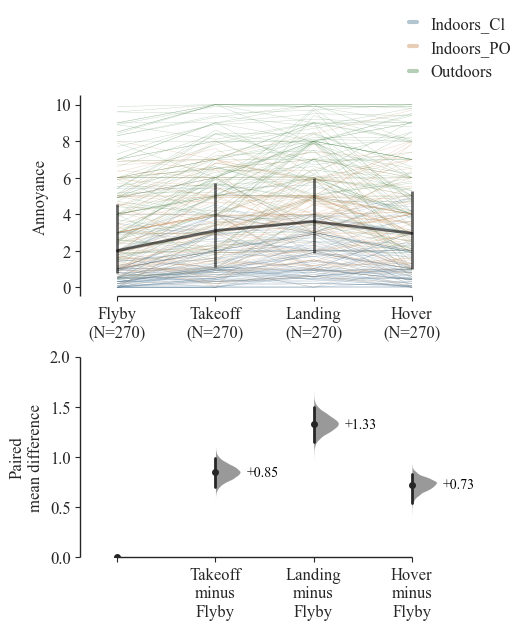

In [89]:
# create dummy pairing ID for each participant to allow for paired analysis
grouping_cols = ['ID', 'Location', 'UASType']

# ngroup() automatically assigns an identical integer to matching sets
# across the different flight-operation conditions
dataDNoiseLong['dummyID'] = dataDNoiseLong.groupby(grouping_cols).ngroup() + 1
dataDNoiseLong.sort_values(by=['dummyID', 'ID', 'StimFile'], inplace=True)

dataDNoiseloadBL = dabest.load(ps_adjust=True, data=dataDNoiseLong, idx=("Flyby", "Takeoff", "Landing", "Hover"),
                               x='UASOperation', y='Annoyance', paired='baseline',
                               id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=646)

dataDNoiseBL = dataDNoiseloadBL.mean_diff.plot(contrast_bars=False,
                                               group_summaries='median_quartiles',
                                   raw_ylim=(-0.5, 10.5), color_col='Location',
                                               delta_dot=False,
                                               contrast_paired_lines=False,
                                               slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.4},
                                               delta_text=True,
                                               contrast_marker_size=4, contrast_ylim=(0, 2),
                                               legend_kwargs={'loc': 'lower center'})



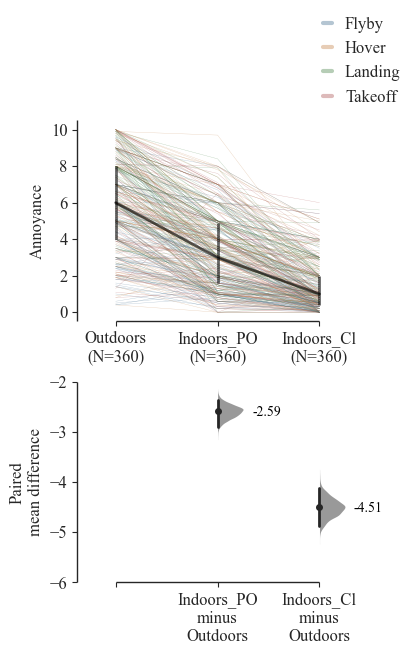

In [90]:
# create dummy pairing ID for each participant to allow for paired analysis
grouping_cols = ['ID', 'UASOperation', 'UASType']

# ngroup() automatically assigns an identical integer to matching sets
# across the different location conditions
dataDNoiseLong['dummyID'] = dataDNoiseLong.groupby(grouping_cols).ngroup() + 1
dataDNoiseLong.sort_values(by=['dummyID', 'ID', 'StimFile'], inplace=True)

dataDNoiseloadBL = dabest.load(ps_adjust=True, data=dataDNoiseLong, idx=("Outdoors", "Indoors_PO", "Indoors_Cl"),
                               x='Location', y='Annoyance', paired='baseline',
                               id_col='dummyID', cluster_col='ID', resamples=5000, random_seed=646)

dataDNoiseBL = dataDNoiseloadBL.mean_diff.plot(contrast_bars=False,
                                               group_summaries='median_quartiles',
                                   raw_ylim=(-0.5, 10.5), color_col='UASOperation',
                                               delta_dot=False,
                                               contrast_paired_lines=False,
                                               slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.4},
                                               delta_text=True,
                                               contrast_marker_size=4, contrast_ylim=(-6, -2),
                                               legend_kwargs={'loc': 'lower center'})